# Capítulo 3: 3 GettingStarted

Este cuaderno unificado contiene todos los ejemplos y ejercicios del capítulo.
Puede ejecutarse de forma independiente en Google Colab.

**Nota:** Este cuaderno incluye automáticamente todas las funciones compartidas necesarias.

## Funciones Compartidas

Esta sección contiene todas las funciones compartidas necesarias para ejecutar los ejemplos.
Puedes colapsar esta sección haciendo clic en el encabezado.

**Nota:** Estas funciones se cargan automáticamente al inicio del cuaderno.

(shared_functions)=
# Funciones compartidas

Este cuaderno contiene funciones que se reutilizan comúnmente en el libro, para cargar y guardar datos, ajustar y evaluar modelos de predicción, o graficar resultados. 

El cuaderno se puede descargar desde GitHub con

```
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.ipynb

```

El cuaderno se puede incluir en otros cuadernos usando

```
%run shared_functions
```



## Imports generales

In [51]:
# Generales
import os
import pandas as pd
import numpy as np
import math
import sys
import time
import pickle
import json
import datetime
import random

#import sklearn
import sklearn
from sklearn import *

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

import graphviz
import xgboost

# Para aprendizaje con datos desbalanceados
import imblearn

import warnings
warnings.filterwarnings('ignore')



## Carga y guardado de datos

### read_from_files

Primer uso en [Capítulo 3, Transformación de Características Baseline](Baseline_Feature_Transformation).

In [52]:
# Cargar un conjunto de archivos pickle, juntarlos en un solo DataFrame, y ordenarlos por tiempo
# Toma como entrada la carpeta DIR_INPUT donde se almacenan los archivos, y BEGIN_DATE y END_DATE
def read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE):
    
    files = [os.path.join(DIR_INPUT, f) for f in os.listdir(DIR_INPUT) if f>=BEGIN_DATE+'.pkl' and f<=END_DATE+'.pkl']

    frames = []
    for f in files:
        df = pd.read_pickle(f)
        frames.append(df)
        del df
    df_final = pd.concat(frames)
    
    df_final=df_final.sort_values('TRANSACTION_ID')
    df_final.reset_index(drop=True,inplace=True)
    #  Nota: -1 son valores faltantes para datos del mundo real 
    df_final=df_final.replace([-1],0)
    
    return df_final


### save_object


In [53]:
# Guardar objeto como archivo pickle
def save_object(obj, filename):
    with open(filename, 'wb') as output:
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)


## Preprocesamiento de datos

### scaleData

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [54]:
def scaleData(train,test,features):
    scaler = sklearn.preprocessing.StandardScaler()
    scaler.fit(train[features])
    train[features]=scaler.transform(train[features])
    test[features]=scaler.transform(test[features])
    
    return (train,test)

## Estrategias de división Train/Test

### get_train_test_set

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Ratio de muestreo agregado en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [55]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7,
                       sampling_ratio=1.0,
                       random_state=0):
    
    # Obtener los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtener los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtener clientes conocidos como defraudados del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtener el día inicial relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtener datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Tarjetas comprometidas de ese día de prueba, menos el período de retraso, se agregan al grupo de clientes conocidos como defraudados
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Si submuestreo
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Ordenar conjuntos de datos por orden ascendente de ID de transacción
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)
                               


In [56]:
def get_train_delay_test_set(transactions_df,
                             start_date_training,
                             delta_train=7,delta_delay=7,delta_test=7,
                             sampling_ratio=1.0,
                             random_state=0):
    
    # Obtener los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtener los datos del conjunto de retraso
    delay_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training+datetime.timedelta(days=delta_train)) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train)+
                                                                               +datetime.timedelta(days=delta_delay))]
    
    # Obtener los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtener clientes conocidos como defraudados del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtener el día inicial relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtener datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Tarjetas comprometidas de ese día de prueba, menos el período de retraso, se agregan al grupo de clientes conocidos como defraudados
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Si submuestreo
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Ordenar conjuntos de datos por orden ascendente de ID de transacción
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, delay_df, test_df)

### prequentialSplit

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [57]:
def prequentialSplit(transactions_df,
                     start_date_training, 
                     n_folds=4, 
                     delta_train=7,
                     delta_delay=7,
                     delta_assessment=7):
    
    prequential_split_indices=[]
        
        # Para cada fold
    for fold in range(n_folds):
        
        # Desplazar hacia atrás la fecha de inicio para entrenamiento por el índice del fold veces el período de evaluación (delta_assessment)
        # (Ver Fig. 5)
        start_date_training_fold = start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Obtener los conjuntos de entrenamiento y prueba (evaluación)
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_assessment)
        
        # Obtener los índices de los dos conjuntos, y agregarlos a la lista de divisiones prequenciales
        indices_train=list(train_df.index)
        indices_test=list(test_df.index)
        
        prequential_split_indices.append((indices_train,indices_test))
    
    return prequential_split_indices


## Predictions functions

### fit_model_and_get_predictions

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [58]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # Por defecto, escala los datos de entrada
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # Primero entrenamos el clasificador usando el método `fit`, y pasamos como argumentos las características de entrada y salida
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # Luego obtenemos las predicciones en los datos de entrenamiento y prueba usando el método `predict_proba`
    # Las predicciones se retornan como un array de numpy, que proporciona la probabilidad de fraude para cada transacción 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # El resultado se retorna como un diccionario que contiene los modelos ajustados, 
    # y las predicciones en los conjuntos de entrenamiento y prueba
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

## Evaluación del rendimiento

### card_precision_top_k_day

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas Precision_top_K](Precision_Top_K_Metrics).

In [59]:
def card_precision_top_k_day(df_day,top_k):
    
    # Esto toma el máximo de las predicciones Y el máximo de la etiqueta TX_FRAUD para cada CUSTOMER_ID, 
    # y ordena por orden decreciente de predicción fraudulenta
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Obtener las k tarjetas más sospechosas
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Calcular precisión top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k



### card_precision_top_k

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas Precision_top_K](Precision_Top_K_Metrics).

In [60]:
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Ordenar días por orden creciente
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # Al principio, la lista de tarjetas comprometidas detectadas está vacía
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # Para cada día, calcular precisión top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Eliminemos las tarjetas comprometidas detectadas del conjunto de transacciones diarias
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Actualicemos la lista de tarjetas comprometidas detectadas
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Calcular la media
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Retorna la precisión top k por día como una lista, y la media resultante
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k



### card_precision_top_k_custom

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [61]:
def card_precision_top_k_custom(y_true, y_pred, top_k, transactions_df):
    
    # Creemos un DataFrame predictions_df, que contiene todas las transacciones que coinciden con los índices del pliegue actual
    # (índices del vector y_true)
    predictions_df=transactions_df.iloc[y_true.index.values].copy()
    predictions_df['predictions']=y_pred
    
    # Calcular el CP@k usando la función implementada en el Capítulo 4, Sección 4.2
    nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k=\
        card_precision_top_k(predictions_df, top_k)
    
    # Retornar el mean_card_precision_top_k
    return mean_card_precision_top_k


### performance_assessment

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [62]:
def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances


### performance_assessment_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [63]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

### execution_times_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [64]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

### get_class_from_fraud_probability

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [65]:
# Obtener clases a partir de un vector de probabilidades de fraude y un umbral
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):
    
    predicted_classes = [0 if fraud_probability<threshold else 1 
                         for fraud_probability in fraud_probabilities]

    return predicted_classes


### threshold_based_metrics

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [66]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):
    
    results = []
    
    for threshold in thresholds_list:
    
        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)
    
        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()
    
        MME = (FP+FN)/(TN+FP+FN+TP)
    
        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)
    
        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)
        
        BER = 1/2*(FPR+FNR)
        
        Gmean = np.sqrt(TPR*TNR)
    
        precision = 1 # 1 if TP+FP=0
        FDR = 1 # 1 if TP+FP=0
        
        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)
        
        NPV = 1 # 1 if TN+FN=0
        FOR = 1 # 1 if TN+FN=0
        
        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)
            
        
        F1_score = 2*(precision*TPR)/(precision+TPR)
    
        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])
        
    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])
    
    return results_df

### get_summary_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [67]:
def get_summary_performances(performances_df, parameter_column_name="Parameters summary"):

    metrics = ['AUC ROC','Average precision','Card Precision@100']
    performances_results=pd.DataFrame(columns=metrics)
    
    performances_df.reset_index(drop=True,inplace=True)

    best_estimated_parameters = []
    validation_performance = []
    test_performance = []
    
    for metric in metrics:
    
        index_best_validation_performance = performances_df.index[np.argmax(performances_df[metric+' Validation'].values)]
    
        best_estimated_parameters.append(performances_df[parameter_column_name].iloc[index_best_validation_performance])
        
        validation_performance.append(
                str(round(performances_df[metric+' Validation'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Validation'+' Std'].iloc[index_best_validation_performance],2))
        )
        
        test_performance.append(
                str(round(performances_df[metric+' Test'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Test'+' Std'].iloc[index_best_validation_performance],2))
        )
    
    performances_results.loc["Best estimated parameters"]=best_estimated_parameters
    performances_results.loc["Validation performance"]=validation_performance
    performances_results.loc["Test performance"]=test_performance

    optimal_test_performance = []
    optimal_parameters = []

    for metric in ['AUC ROC Test','Average precision Test','Card Precision@100 Test']:
    
        index_optimal_test_performance = performances_df.index[np.argmax(performances_df[metric].values)]
    
        optimal_parameters.append(performances_df[parameter_column_name].iloc[index_optimal_test_performance])
    
        optimal_test_performance.append(
                str(round(performances_df[metric].iloc[index_optimal_test_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Std'].iloc[index_optimal_test_performance],2))
        )

    performances_results.loc["Optimal parameter(s)"]=optimal_parameters
    performances_results.loc["Optimal test performance"]=optimal_test_performance
    
    return performances_results

### model_selection_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [68]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC'):
    
    # Nota: max_depth de 50 es similar a None
    default_parameters_dictionary={
        "Decision Tree": 50,
        "Logstic Regression": 1,
        "Random Forest": "100/50",
        "XGBoost": "100/0.1/2"
    }
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class, performances_df in performances_df_dictionary.items():
        
        # Obtener los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtener los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtener los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Retornar los rendimientos promedio y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

In [69]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC',
                                 model_classes=['Decision Tree', 
                                                'Logistic Regression', 
                                                'Random Forest', 
                                                'XGBoost'],
                                 default_parameters_dictionary={
                                                "Decision Tree": 50,
                                                "Logistic Regression": 1,
                                                "Random Forest": "100/50",
                                                "XGBoost": "100/0.1/3"
                                            }):
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class in model_classes:
        
        performances_df=performances_df_dictionary[model_class]
        
        # Obtener los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtener los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtener los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Retornar los rendimientos promedio y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

## Model selection

### prequential_grid_search

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [70]:
def prequential_grid_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=grid_search.cv_results_['params']
    performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']
    
    return performances_df



### model_selection_wrapper

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [71]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):

    # Obtener rendimientos en el conjunto de validación usando validación prequencial
    performances_df_validation=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Obtener rendimientos en el conjunto de prueba usando validación prequencial
    performances_df_test=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Unir los dos DataFrames resultantes
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df


### kfold_cv_with_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [72]:
def kfold_cv_with_classifier(classifier,
                             X,
                             y,
                             n_splits=5,
                             strategy_name="Basline classifier"):
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_=sklearn.model_selection.cross_validate(classifier,X,y,cv=cv,
                                                       scoring=['roc_auc',
                                                                'average_precision',
                                                                'balanced_accuracy'],
                                                       return_estimator=True)
    
    results=round(pd.DataFrame(cv_results_),3)
    results_mean=list(results.mean().values)
    results_std=list(results.std().values)
    results_df=pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                              str(round(results_std[i],3)) for i in range(len(results))]],
                            columns=['Fit time (s)','Score time (s)',
                                     'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0=cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    train_df=pd.DataFrame({'X1':X[train_index,0],'X2':X[train_index,1], 'Y':y[train_index]})
    test_df=pd.DataFrame({'X1':X[test_index,0],'X2':X[test_index,1], 'Y':y[test_index]})
    
    return (results_df, classifier_0, train_df, test_df)

## Graficado

### get_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [73]:
# Calcular el número de transacciones por día, transacciones fraudulentas por día y tarjetas fraudulentas por día

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_compromised_card_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_card_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats



### get_template_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [74]:
# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_training+datetime.timedelta(days=delta_train+delta_delay), 0, ylim, color="black")
    
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


### get_template_roc_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [75]:
def get_template_roc_curve(ax, title,fs,random=True):
    
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('False Positive Rate', fontsize=fs)
    ax.set_ylabel('True Positive Rate', fontsize=fs)
    
    if random:
        ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")



### get_template_pr_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [76]:
def get_template_pr_curve(ax, title,fs, baseline=0.5):
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('Recall (True Positive Rate)', fontsize=fs)
    ax.set_ylabel('Precision', fontsize=fs)
    
    ax.plot([0, 1], [baseline, baseline],'r--',label='AP Random = {0:0.3f}'.format(baseline))


### get_performance_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [77]:
# Obtener el gráfico de rendimiento para una única métrica de rendimiento
def get_performance_plot(performances_df, 
                         ax, 
                         performance_metric, 
                         expe_type_list=['Test','Train'], 
                         expe_type_color_list=['#008000','#2F4D7E'],
                         parameter_name="Tree maximum depth",
                         summary_performances=None):
    
    # expe_type_list es la lista de tipos de experimentos, típicamente contiene 'Test', 'Train', o 'Valid'
    # Para todos los tipos de experimentos
    for i in range(len(expe_type_list)):
    
        # Columna en performances_df para la cual recuperar los datos 
        performance_metric_expe_type=performance_metric+' '+expe_type_list[i]
    
        # Graficar datos en el gráfico
        ax.plot(performances_df['Parameters summary'], performances_df[performance_metric_expe_type], 
                color=expe_type_color_list[i], label = expe_type_list[i])
        
        # Si performances_df contiene intervalos de confianza, agregarlos al gráfico
        if performance_metric_expe_type+' Std' in performances_df.columns:
        
            conf_min = performances_df[performance_metric_expe_type]\
                        -2*performances_df[performance_metric_expe_type+' Std']
            conf_max = performances_df[performance_metric_expe_type]\
                        +2*performances_df[performance_metric_expe_type+' Std']
    
            ax.fill_between(performances_df['Parameters summary'], conf_min, conf_max, color=expe_type_color_list[i], alpha=.1)

    # Si la tabla summary_performances está presente, agrega una barra vertical punteada para el mejor parámetro estimado 
    if summary_performances is not None:
        best_estimated_parameter=summary_performances[performance_metric][['Best estimated parameters']].values[0]
        best_estimated_performance=float(summary_performances[performance_metric][['Validation performance']].values[0].split("+/-")[0])
        ymin, ymax = ax.get_ylim()
        ax.vlines(best_estimated_parameter, ymin, best_estimated_performance,
                  linestyles="dashed")
    
    # Establecer título, y etiquetas de ejes x e y
    ax.set_title(performance_metric+'\n', fontsize=14)
    ax.set(xlabel = parameter_name, ylabel=performance_metric)
    

### get_performances_plots

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [78]:
# Obtener los gráficos de rendimiento para un conjunto de métricas de rendimiento
def get_performances_plots(performances_df, 
                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                           expe_type_list=['Test','Train'], expe_type_color_list=['#008000','#2F4D7E'],
                           parameter_name="Tree maximum depth",
                           summary_performances=None):
    
    # Crear tantos gráficos como métricas de rendimiento haya para mostrar
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    # Graficar métrica de rendimiento para cada métrica en performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_performance_plot(performances_df, ax[i], performance_metric=performance_metrics_list[i], 
                             expe_type_list=expe_type_list, 
                             expe_type_color_list=expe_type_color_list,
                             parameter_name=parameter_name,
                             summary_performances=summary_performances)
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=expe_type_list, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Type set")

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### get_execution_times_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [79]:
# Obtener el gráfico de rendimiento para una única métrica de rendimiento
def get_execution_times_plot(performances_df,
                             title="",
                             parameter_name="Tree maximum depth"):
    
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    
    # Graficar datos en el gráfico
    ax.plot(performances_df['Parameters summary'], performances_df["Execution time"], 
            color="black")
        
    # Establecer título, y etiquetas de ejes x e y
    ax.set_title(title, fontsize=14)
    ax.set(xlabel = parameter_name, ylabel="Execution time (seconds)")

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [80]:
    # Obtener el gráfico de rendimiento para una única métrica de rendimiento
def get_model_selection_performance_plot(performances_df_dictionary, 
                                         ax, 
                                         performance_metric,
                                         ylim=[0,1],
                                         model_classes=['Decision Tree', 
                                                        'Logistic Regression', 
                                                        'Random Forest', 
                                                        'XGBoost']):
    
    
    (mean_performances_dictionary,std_performances_dictionary) = \
        model_selection_performances(performances_df_dictionary=performances_df_dictionary,
                                     performance_metric=performance_metric)
    
    
    # ancho de las barras
    barWidth = 0.3
    # La posición x de las barras
    r1 = np.arange(len(model_classes))
    r2 = r1+barWidth
    r3 = r1+2*barWidth
    
    # Crear barras de parámetros por defecto (Naranja)
    ax.bar(r1, mean_performances_dictionary['Default parameters'], 
           width = barWidth, color = '#CA8035', edgecolor = 'black', 
           yerr=std_performances_dictionary['Default parameters'], capsize=7, label='Default parameters')
 
    # Crear barras de mejores parámetros de validación (Rojo)
    ax.bar(r2, mean_performances_dictionary['Best validation parameters'], 
           width = barWidth, color = '#008000', edgecolor = 'black', 
           yerr=std_performances_dictionary['Best validation parameters'], capsize=7, label='Best validation parameters')

    # Crear barras de parámetros óptimos (Verde)
    ax.bar(r3, mean_performances_dictionary['Optimal parameters'], 
           width = barWidth, color = '#2F4D7E', edgecolor = 'black', 
           yerr=std_performances_dictionary['Optimal parameters'], capsize=7, label='Optimal parameters')
 

    # Establecer título, y etiquetas de ejes x e y
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xticks(r2+barWidth/2)
    ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
    ax.set_title(performance_metric+'\n', fontsize=18)
    ax.set_xlabel("Model class", fontsize=16)
    ax.set_ylabel(performance_metric, fontsize=15)

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [81]:
def get_model_selection_performances_plots(performances_df_dictionary, 
                                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                           ylim_list=[[0.6,0.9],[0.2,0.8],[0.2,0.35]],
                                           model_classes=['Decision Tree', 
                                                          'Logistic Regression', 
                                                          'Random Forest', 
                                                          'XGBoost']):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    parameter_types=['Default parameters','Best validation parameters','Optimal parameters']
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_model_selection_performance_plot(performances_df_dictionary, 
                                             ax[i], 
                                             performance_metrics_list[i],
                                             ylim=ylim_list[i],
                                             model_classes=model_classes
                                            )
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=parameter_types, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Parameter type",
                                       prop={'size': 12},
                                       title_fontsize=12)

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### plot_decision_boundary_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [82]:
def plot_decision_boundary_classifier(ax, 
                                      classifier,
                                      train_df,
                                      input_features=['X1','X2'],
                                      output_feature='Y',
                                      title="",
                                      fs=14,
                                      plot_training_data=True):

    plot_colors = ["tab:blue","tab:orange"]

    x1_min, x1_max = train_df[input_features[0]].min() - 1, train_df[input_features[0]].max() + 1
    x2_min, x2_max = train_df[input_features[1]].min() - 1, train_df[input_features[1]].max() + 1
    
    plot_step=0.1
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                         np.arange(x2_min, x2_max, plot_step))

    Z = classifier.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu_r,alpha=0.3)

    if plot_training_data:
        # Plot the training points
        groups = train_df.groupby(output_feature)
        for name, group in groups:
            ax.scatter(group[input_features[0]], group[input_features[1]], edgecolors='black', label=name)
        
    ax.set_title(title, fontsize=fs)
    ax.set_xlabel(input_features[0], fontsize=fs)
    ax.set_ylabel(input_features[1], fontsize=fs)

### plot_decision_boundary

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [83]:
def plot_decision_boundary(classifier_0,
                           train_df, 
                           test_df):
    
    fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))

    plot_decision_boundary_classifier(ax[0], classifier_0,
                                  train_df,
                                  title="Superficie de decisión del árbol de decisión\n Con datos de entrenamiento",
                                  plot_training_data=True)

    plot_decision_boundary_classifier(ax[1], classifier_0,
                                  train_df,
                                  title="Superficie de decisión del árbol de decisión\n",
                                  plot_training_data=False)


    plot_decision_boundary_classifier(ax[2], classifier_0,
                                  test_df,
                                  title="Superficie de decisión del árbol de decisión\n Con datos de prueba",
                                  plot_training_data=True)

    ax[-1].legend(loc='upper left', 
              #labels=[0,1], 
              bbox_to_anchor=(1.05, 1),
              title="Clase")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
    fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))
    
    return fig_decision_boundary

## Deep Learning functions



In [84]:
import torch
import torch.nn.functional as F

### seed_everything

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [85]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

### Utilidades para gestión de datos, entrenamiento y evaluación

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [86]:
class FraudDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Inicialización'
        self.x = x
        self.y = y

    def __len__(self):
        'Denota el número total de muestras'
        return len(self.x)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Seleccionar índice de muestra
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index]

def prepare_generators(training_set,valid_set,batch_size=64):
    
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator

def evaluate_model(model,generator,criterion):
    model.eval()
    batch_losses = []
    for x_batch, y_batch in generator:
        # Paso hacia adelante
        y_pred = model(x_batch)
        # Calcular pérdida
        loss = criterion(y_pred.squeeze(), y_batch)
        batch_losses.append(loss.item())
    mean_loss = np.mean(batch_losses)    
    return mean_loss

class EarlyStopping:
    
    def __init__(self, patience=2, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = np.Inf
    
    def continue_training(self,current_score):
        if self.best_score > current_score:
            self.best_score = current_score
            self.counter = 0
            if self.verbose:
                print("Nueva mejor puntuación:", current_score)
        else:
            self.counter+=1
            if self.verbose:
                print(self.counter, " iteraciones desde la mejor puntuación.")
                
        return self.counter <= self.patience  
    
def training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=100,apply_early_stopping=True,patience=2,verbose=False):
    #Setting the model in training mode
    model.train()

    if apply_early_stopping:
        early_stopping = EarlyStopping(verbose=verbose,patience=patience)
    
    all_train_losses = []
    all_valid_losses = []
    
    #Training loop
    start_time=time.time()
    for epoch in range(max_epochs):
        model.train()
        train_loss=[]
        for x_batch, y_batch in training_generator:
            optimizer.zero_grad()
            # Paso hacia adelante
            y_pred = model(x_batch)
            # Calcular pérdida
            loss = criterion(y_pred.squeeze(), y_batch)
            # Paso hacia atrás
            loss.backward()
            optimizer.step()   
            train_loss.append(loss.item())
        
        # mostrar la última pérdida de entrenamiento después de cada época
        all_train_losses.append(np.mean(train_loss))
        if verbose:
            print('')
            print('Época {}: pérdida de entrenamiento: {}'.format(epoch, np.mean(train_loss)))
        # evaluar el modelo en el conjunto de prueba después de cada época    
        valid_loss = evaluate_model(model,valid_generator,criterion)
        all_valid_losses.append(valid_loss)
        if verbose:
            print('pérdida de validación: {}'.format(valid_loss))
        if apply_early_stopping:
            if not early_stopping.continue_training(valid_loss):
                if verbose:
                    print("Detención temprana")
                break
        
    training_execution_time=time.time()-start_time
    return model,training_execution_time,all_train_losses,all_valid_losses

def per_sample_mse(model,generator):
    model.eval()
    criterion = torch.nn.MSELoss(reduction="none")
    batch_losses = []
    for x_batch, y_batch in generator:
        # Paso hacia adelante
        y_pred = model(x_batch)
        # Calcular pérdida
        loss = criterion(y_pred.squeeze(), y_batch)
        loss_app = list(torch.mean(loss,axis=1).detach().numpy())
        batch_losses.extend(loss_app)
    return batch_losses

class FraudDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Inicialización'
        self.x = torch.FloatTensor(x)
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
        

    def __len__(self):
        'Denota el número total de muestras'
        return len(self.x)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Seleccionar índice de muestra
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index], -1  
        
def rolling_window(array, window):
    a = np.concatenate([np.ones((window-1,))*-1,array])
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides).astype(int)

### FraudDatasetUnsupervised

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [87]:
class FraudDatasetUnsupervised(torch.utils.data.Dataset):
    
    def __init__(self, x,output=True):
        'Inicialización'
        self.x = x
        self.output = output

    def __len__(self):
        'Denota el número total de muestras'
        return len(self.x)

    def __getitem__(self, index):
        'Genera una muestra de datos'
        # Seleccionar índice de muestra
        if self.output:
            return self.x[index], self.x[index]
        else:
            return self.x[index]

### Módulos SimpleFraudMLPWithDropout y FraudMLP

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [88]:
class SimpleFraudMLPWithDropout(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size,p):
            super(SimpleFraudMLPWithDropout, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output
        
class FraudMLP(torch.nn.Module):
    
        def __init__(self, input_size,hidden_size=100,num_layers=1,p=0):
            super(FraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            self.fc_hidden=[]
            for i in range(num_layers-1):
                self.fc_hidden.append(torch.nn.Linear(self.hidden_size, self.hidden_size))
                self.fc_hidden.append(torch.nn.ReLU())
                
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 2)
            self.softmax = torch.nn.Softmax()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)             
            hidden = self.dropout(hidden)
            
            for layer in self.fc_hidden:
                hidden=layer(hidden)
                hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.softmax(output)
            
            return output

### Módulo SimpleAutoencoder

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [89]:
class SimpleAutoencoder(torch.nn.Module):
    
        def __init__(self, input_size, intermediate_size, code_size):
            super(SimpleAutoencoder, self).__init__()
            # parameters
            self.input_size = input_size
            self.intermediate_size = intermediate_size           
            self.code_size  = code_size
            
            self.relu = torch.nn.ReLU()   
            
            # codificador
            self.fc1 = torch.nn.Linear(self.input_size, self.intermediate_size)
            self.fc2 = torch.nn.Linear(self.intermediate_size, self.code_size)
            
            # decodificador 
            self.fc3 = torch.nn.Linear(self.code_size, self.intermediate_size)            
            self.fc4 = torch.nn.Linear(self.intermediate_size, self.input_size)
            
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            code = self.fc2(hidden)
            code = self.relu(code)
 
            hidden = self.fc3(code)
            hidden = self.relu(hidden)
            
            output = self.fc4(hidden)
            #linear activation in final layer)            
            
            return output

### Módulo Attention

Primer uso en [Capítulo 7, Modelos secuenciales y aprendizaje de representación](SequentialModeling).

In [90]:
# fuente : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

class Attention(torch.nn.Module):
    r"""
    Aplica un mecanismo de atención sobre las características de salida del decodificador.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): El número de características esperadas en la salida
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor que contiene las características de salida del decodificador.
        - **context** (batch, input_len, dimensions): tensor que contiene características de la secuencia de entrada codificada.
    Salidas: output, attn
        - **output** (batch, output_len, dimensions): tensor que contiene las características de salida atendidas del decodificador.
        - **attn** (batch, output_len, input_len): tensor que contiene los pesos de atención.
    Atributos:
        linear_out (torch.nn.Linear): aplica una transformación lineal a los datos entrantes: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): aplica un :math:`-inf` a los índices especificados en el `Tensor`.
    Ejemplos::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Establece los índices a enmascarar
        Args:
            mask (torch.Tensor): tensor que contiene los índices a enmascarar
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn


---

**Fin de Funciones Compartidas**


---

## SimulatedDataset


(Transaction_data_Simulator)=
# Simulador de datos de transacciones


Esta sección presenta un simulador de datos de transacciones de transacciones legítimas y fraudulentas. Este simulador se utilizará a lo largo del resto de este libro para motivar y evaluar la eficiencia de diferentes técnicas de detección de fraude de manera reproducible. 

Una simulación es necesariamente una aproximación de la realidad. Comparado con la complejidad de la dinámica subyacente a los datos de transacciones con tarjeta de pago del mundo real, el simulador de datos que presentamos a continuación sigue un diseño simple. 

Este diseño simple es una elección. Primero, tener reglas simples para generar transacciones y comportamientos fraudulentos ayudará a interpretar el tipo de patrones que diferentes técnicas de detección de fraude pueden identificar. Segundo, aunque simple en su diseño, el simulador de datos generará conjuntos de datos que son desafiantes de manejar. 

Los conjuntos de datos simulados resaltarán la mayoría de los problemas que los practicantes de detección de fraude enfrentan usando datos del mundo real. En particular, incluirán desequilibrio de clases (menos del 1% de transacciones fraudulentas), una mezcla de características numéricas y categóricas (con características categóricas que involucran un número muy grande de valores), relaciones no triviales entre características, y escenarios de fraude dependientes del tiempo.

<h3>Decisiones de diseño</h3>

<h4>Características de transacción</h4>

Nuestro enfoque estará en las características más esenciales de una transacción. En esencia, una transacción con tarjeta de pago consiste en cualquier monto pagado a un comerciante por un cliente en un momento determinado. Las seis características principales que resumen una transacción por lo tanto son:

1. El ID de transacción: Un identificador único para la transacción
2. La fecha y hora: Fecha y hora en la que ocurre la transacción
3. El ID del cliente: El identificador del cliente. Cada cliente tiene un identificador único
4. El ID del terminal: El identificador del comerciante (o más precisamente el terminal). Cada terminal tiene un identificador único
5. El monto de la transacción: El monto de la transacción.
6. La etiqueta de fraude: Una variable binaria, con el valor $0$ para una transacción legítima, o el valor $1$ para una transacción fraudulenta.

Estas características se referirán como `TRANSACTION_ID`, `TX_DATETIME`, `CUSTOMER_ID`, `TERMINAL_ID`, `TX_AMOUNT`, y `TX_FRAUD`. 

El objetivo del simulador de datos de transacciones será generar una tabla de transacciones con estas características. Esta tabla se referirá como la tabla de *transacciones etiquetadas*. Tal tabla se ilustra en la Fig. 1. 

![alt text](images/tx_table.png)
<p style="text-align: center;">
Fig. 1. Ejemplo de tabla de transacciones etiquetadas. Cada transacción se representa como una fila en la tabla,<br> junto con su etiqueta (variable TX_FRAUD, 0 para legítimas, y 1 para transacciones fraudulentas).
</p>
    


In [91]:
# Imports necesarios para este cuaderno
import os

import numpy as np
import pandas as pd

import datetime
import time

import random

# Para graficar
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})


## Generación de perfiles de clientes

Cada cliente será definido por las siguientes propiedades:

* `CUSTOMER_ID`: El ID único del cliente
* (`x_customer_id`,`y_customer_id`): Un par de coordenadas reales (`x_customer_id`,`y_customer_id`) en una cuadrícula de 100 * 100, que define la ubicación geográfica del cliente
* (`mean_amount`, `std_amount`):  La media y desviación estándar de los montos de transacción para el cliente, asumiendo que los montos de transacción siguen una distribución normal. El `mean_amount` se extraerá de una distribución uniforme (5,100) y el `std_amount` se establecerá como el `mean_amount` dividido por dos. 
* `mean_nb_tx_per_day`:  El número promedio de transacciones por día para el cliente, asumiendo que el número de transacciones por día sigue una distribución de Poisson. Este número se extraerá de una distribución uniforme (0,4). 

La función `generate_customer_profiles_table` proporciona una implementación para generar una tabla de perfiles de clientes. Toma como entrada el número de clientes para los cuales generar un perfil y un estado aleatorio para reproducibilidad. Retorna un DataFrame que contiene las propiedades para cada cliente. 

<h4>Proceso de generación de transacciones</h4>

La simulación consistirá en cinco pasos principales:

1. Generación de perfiles de clientes: Cada cliente es diferente en sus hábitos de gasto. Esto se simulará definiendo algunas propiedades para cada cliente. Las propiedades principales serán su ubicación geográfica, su frecuencia de gasto, y sus montos de gasto. Las propiedades del cliente se representarán como una tabla, referida como la *tabla de perfiles de clientes*. 
2. Generación de perfiles de terminales: Las propiedades del terminal simplemente consistirán en una ubicación geográfica. Las propiedades del terminal se representarán como una tabla, referida como la *tabla de perfiles de terminales*.
3. Asociación de perfiles de clientes a terminales: Asumiremos que los clientes solo hacen transacciones en terminales que están dentro de un radio de $r$ de sus ubicaciones geográficas. Esto hace la suposición simple de que un cliente solo hace transacciones en terminales que están geográficamente cerca de su ubicación. Este paso consistirá en agregar una característica 'list_terminals' a cada perfil de cliente, que contiene el conjunto de terminales que un cliente puede usar.
4. Generación de transacciones: El simulador iterará sobre el conjunto de perfiles de clientes, y generará transacciones de acuerdo con sus propiedades (frecuencias y montos de gasto, y terminales disponibles). Esto resultará en una tabla de transacciones.
5. Generación de escenarios de fraude: Este último paso etiquetará las transacciones como legítimas o genuinas. Esto se hará siguiendo tres escenarios de fraude diferentes.

El proceso de generación de transacciones se ilustra a continuación. 

![alt text](images/FlowDatasetGenerator.png)
<p style="text-align: center;">
Fig. 2. Proceso de generación de transacciones. Los perfiles de clientes y terminales se usan para generar  <br> un conjunto de transacciones. El paso final, que genera escenarios de fraude, proporciona la tabla de transacciones etiquetadas.
  

Las siguientes secciones detallan la implementación para cada uno de estos pasos. 
    

In [92]:
def generate_customer_profiles_table(n_customers, random_state=0):
    
    np.random.seed(random_state)
        
    customer_id_properties=[]
    
    # Generar propiedades de clientes a partir de distribuciones aleatorias 
    for customer_id in range(n_customers):
        
        x_customer_id = np.random.uniform(0,100)
        y_customer_id = np.random.uniform(0,100)
        
        mean_amount = np.random.uniform(5,100) # Arbitrary (but sensible) value 
        std_amount = mean_amount/2 # Arbitrary (but sensible) value
        
        mean_nb_tx_per_day = np.random.uniform(0,4) # Arbitrary (but sensible) value 
        
        customer_id_properties.append([customer_id,
                                      x_customer_id, y_customer_id,
                                      mean_amount, std_amount,
                                      mean_nb_tx_per_day])
        
    customer_profiles_table = pd.DataFrame(customer_id_properties, columns=['CUSTOMER_ID',
                                                                      'x_customer_id', 'y_customer_id',
                                                                      'mean_amount', 'std_amount',
                                                                      'mean_nb_tx_per_day'])
    
    return customer_profiles_table

Como ejemplo, generemos una tabla de perfiles de clientes para cinco clientes:

In [93]:
n_customers = 5
customer_profiles_table = generate_customer_profiles_table(n_customers, random_state = 0)
customer_profiles_table

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day
0,0,54.881350,71.518937,62.262521,31.131260,2.179533
1,1,42.365480,64.589411,46.570785,23.285393,3.567092
2,2,96.366276,38.344152,80.213879,40.106939,2.115580
3,3,56.804456,92.559664,11.748426,5.874213,0.348517
4,4,2.021840,83.261985,78.924891,39.462446,3.480049


## Generación de perfiles de terminales

Cada terminal será definido por las siguientes propiedades:

* `TERMINAL_ID`: El ID del terminal
* (`x_terminal_id`,`y_terminal_id`): Un par de coordenadas reales (`x_terminal_id`,`y_terminal_id`) en una cuadrícula de 100 * 100, que define la ubicación geográfica del terminal

La función `generate_terminal_profiles_table` proporciona una implementación para generar una tabla de perfiles de terminales. Toma como entrada el número de terminales para los cuales generar un perfil y un estado aleatorio para reproducibilidad. Retorna un DataFrame que contiene las propiedades para cada terminal. 


In [94]:
def generate_terminal_profiles_table(n_terminals, random_state=0):
    
    np.random.seed(random_state)
        
    terminal_id_properties=[]
    
    # Generar propiedades de terminales a partir de distribuciones aleatorias 
    for terminal_id in range(n_terminals):
        
        x_terminal_id = np.random.uniform(0,100)
        y_terminal_id = np.random.uniform(0,100)
        
        terminal_id_properties.append([terminal_id,
                                      x_terminal_id, y_terminal_id])
                                       
    terminal_profiles_table = pd.DataFrame(terminal_id_properties, columns=['TERMINAL_ID',
                                                                      'x_terminal_id', 'y_terminal_id'])
    
    return terminal_profiles_table

Como ejemplo, generemos una tabla de terminales de clientes para cinco terminales:

In [95]:
n_terminals = 5
terminal_profiles_table = generate_terminal_profiles_table(n_terminals, random_state = 0)
terminal_profiles_table

,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,54.881350,71.518937
1,1,60.276338,54.488318
2,2,42.365480,64.589411
3,3,43.758721,89.177300
4,4,96.366276,38.344152


## Asociación de perfiles de clientes a terminales

Asociemos ahora terminales con los perfiles de clientes. En nuestro diseño, los clientes solo pueden realizar transacciones en terminales que están dentro de un radio de `r` de sus ubicaciones geográficas. 

Escribamos primero una función, llamada `get_list_terminals_within_radius`, que encuentra estos terminales para un perfil de cliente. La función tomará como entrada un perfil de cliente (cualquier fila en la tabla de perfiles de clientes), un array que contiene la ubicación geográfica de todos los terminales, y el radio `r`. Retornará la lista de terminales dentro de un radio de `r` para ese cliente. 

In [96]:
def get_list_terminals_within_radius(customer_profile, x_y_terminals, r):
    
    # Usar arrays de numpy en lo siguiente para acelerar los cálculos
    
    # Ubicación (x,y) del cliente como array de numpy
    x_y_customer = customer_profile[['x_customer_id','y_customer_id']].values.astype(float)
    
    # Squared difference in coordinates between customer and terminal locations
    squared_diff_x_y = np.square(x_y_customer - x_y_terminals)
    
    # Sum along rows and compute suared root to get distance
    dist_x_y = np.sqrt(np.sum(squared_diff_x_y, axis=1))
    
    # Obtener los índices de terminales que están a una distancia menor que r
    available_terminals = list(np.where(dist_x_y<r)[0])
    
    # Retornar la lista de IDs de terminales
    return available_terminals
    

Como ejemplo, obtengamos la lista de terminales que están dentro de un radio $r=50$ del último cliente:

In [97]:
# Primero obtenemos las ubicaciones geográficas de todos los terminales como un array de numpy
x_y_terminals = terminal_profiles_table[['x_terminal_id','y_terminal_id']].values.astype(float)
# Y obtener la lista de terminales dentro del radio de $50$ para el último cliente
get_list_terminals_within_radius(customer_profiles_table.iloc[4], x_y_terminals=x_y_terminals, r=50)

[np.int64(2), np.int64(3)]

La lista contiene el tercer y cuarto terminal, que son efectivamente los únicos dentro de un radio de $50$ del último cliente. 

In [98]:
terminal_profiles_table

,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,54.881350,71.518937
1,1,60.276338,54.488318
2,2,42.365480,64.589411
3,3,43.758721,89.177300
4,4,96.366276,38.344152


Para mejor visualización, grafiquemos 

* Las ubicaciones de todos los terminales (en rojo)
* La ubicación del último cliente (en azul)
* La región dentro del radio de 50 del primer cliente (en verde)

In [99]:
# %%capture
# 
# terminals_available_to_customer_fig, ax = plt.subplots(figsize=(5,5))
# 
# # Plot locations of terminals
# ax.scatter(terminal_profiles_table.x_terminal_id.values, 
#            terminal_profiles_table.y_terminal_id.values, 
#            color='blue', label = 'Locations of terminals')
# 
# # Plot location of the last customer
# customer_id=4
# ax.scatter(customer_profiles_table.iloc[customer_id].x_customer_id, 
#            customer_profiles_table.iloc[customer_id].y_customer_id, 
#            color='red',label="Location of last customer")
# 
# ax.legend(loc = 'upper left', bbox_to_anchor=(1.05, 1))
# 
# # Plot the region within a radius of 50 of the last customer
# circ = plt.Circle((customer_profiles_table.iloc[customer_id].x_customer_id,
#                    customer_profiles_table.iloc[customer_id].y_customer_id), radius=50, color='g', alpha=0.2)
# ax.add_patch(circ)
# 
# fontsize=15
# 
# ax.set_title("Green circle: \n Terminals within a radius of 50 \n of the last customer")
# ax.set_xlim([0, 100])
# ax.set_ylim([0, 100])
#     
# ax.set_xlabel('x_terminal_id', fontsize=fontsize)
# ax.set_ylabel('y_terminal_id', fontsize=fontsize)
# 


In [100]:
terminals_available_to_customer_fig

NameError: name 'terminals_available_to_customer_fig' is not defined

Calcular la lista de terminales disponibles para cada cliente es entonces sencillo, usando la función `apply` de pandas. Almacenamos los resultados como una nueva columna `available_terminals` en la tabla de perfiles de clientes.

In [ ]:
customer_profiles_table['available_terminals']=customer_profiles_table.apply(lambda x : get_list_terminals_within_radius(x, x_y_terminals=x_y_terminals, r=50), axis=1)
customer_profiles_table

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,available_terminals
0,0,54.881350,71.518937,62.262521,31.131260,2.179533,"[0, 1, 2, 3]"
1,1,42.365480,64.589411,46.570785,23.285393,3.567092,"[0, 1, 2, 3]"
2,2,96.366276,38.344152,80.213879,40.106939,2.115580,"[1, 4]"
3,3,56.804456,92.559664,11.748426,5.874213,0.348517,"[0, 1, 2, 3]"
4,4,2.021840,83.261985,78.924891,39.462446,3.480049,"[2, 3]"


Vale la pena notar que el radio $r$ controla el número de terminales que estarán en promedio disponibles para cada cliente. A medida que se aumenta el número de terminales, este radio debe adaptarse para igualar el número promedio de terminales disponibles por cliente que se desea en una simulación.  

## Generación de transacciones

Los perfiles de clientes ahora contienen toda la información que requerimos para generar transacciones. La generación de transacciones se hará mediante una función `generate_transactions_table` que toma como entrada un perfil de cliente, una fecha de inicio, y un número de días para los cuales generar transacciones. Retornará una tabla de transacciones, que sigue el formato presentado arriba (sin la etiqueta de transacción, que se agregará en [generación de escenarios de fraude](Fraud_Scenarios_Generation)). 


In [ ]:
def generate_transactions_table(customer_profile, start_date = "2018-04-01", nb_days = 10):
    
    customer_transactions = []
    
    random.seed(int(customer_profile.CUSTOMER_ID))
    np.random.seed(int(customer_profile.CUSTOMER_ID))
    
    # Para todos los días
    for day in range(nb_days):
        
        # Random number of transactions for that day 
        nb_tx = np.random.poisson(customer_profile.mean_nb_tx_per_day)
        
        # Si nb_tx es positivo, generemos transacciones
        if nb_tx>0:
            
            for tx in range(nb_tx):
                
                # Hora de la transacción: Alrededor del mediodía, desviación estándar 20000 segundos. Esta elección tiene como objetivo simular el hecho de que 
                # la mayoría de las transacciones ocurren durante el día.
                time_tx = int(np.random.normal(86400/2, 20000))
                
                # Si el tiempo de transacción está entre 0 y 86400, mantengámoslo, de lo contrario, descartémoslo
                if (time_tx>0) and (time_tx<86400):
                    
                    # El monto se extrae de una distribución normal  
                    amount = np.random.normal(customer_profile.mean_amount, customer_profile.std_amount)
                    
                    # Si el monto es negativo, extraer de una distribución uniforme
                    if amount<0:
                        amount = np.random.uniform(0,customer_profile.mean_amount*2)
                    
                    amount=np.round(amount,decimals=2)
                    
                    if len(customer_profile.available_terminals)>0:
                        
                        terminal_id = random.choice(customer_profile.available_terminals)
                    
                        customer_transactions.append([time_tx+day*86400, day,
                                                      customer_profile.CUSTOMER_ID, 
                                                      terminal_id, amount])
            
    customer_transactions = pd.DataFrame(customer_transactions, columns=['TX_TIME_SECONDS', 'TX_TIME_DAYS', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT'])
    
    if len(customer_transactions)>0:
        customer_transactions['TX_DATETIME'] = pd.to_datetime(customer_transactions["TX_TIME_SECONDS"], unit='s', origin=start_date)
        customer_transactions=customer_transactions[['TX_DATETIME','CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT','TX_TIME_SECONDS', 'TX_TIME_DAYS']]
    
    return customer_transactions  
    
    

Generemos por ejemplo transacciones para el primer cliente, durante cinco días, comenzando en la fecha 2018-04-01:

In [ ]:
transaction_table_customer_0=generate_transactions_table(customer_profiles_table.iloc[0], 
                                                         start_date = "2018-04-01", 
                                                         nb_days = 5)
transaction_table_customer_0

,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
0,2018-04-01 07:19:05,0,3,123.59,26345,0
1,2018-04-01 19:02:02,0,3,46.51,68522,0
2,2018-04-01 18:00:16,0,0,77.34,64816,0
3,2018-04-02 15:13:02,0,2,32.35,141182,1
4,2018-04-02 14:05:38,0,3,63.30,137138,1
5,2018-04-02 15:46:51,0,3,13.59,143211,1
6,2018-04-02 08:51:06,0,2,54.72,118266,1
7,2018-04-02 20:24:47,0,3,51.89,159887,1
8,2018-04-03 12:15:47,0,2,117.91,216947,2
9,2018-04-03 08:50:09,0,1,67.72,204609,2


Podemos hacer una verificación rápida de que las transacciones generadas siguen las propiedades del perfil del cliente:

* Los IDs de terminales son efectivamente aquellos en la lista de terminales disponibles (0, 1, 2 y 3)
* Los montos de transacción parecen seguir los parámetros de monto del cliente (`mean_amount`=62.26 y	`std_amount`=31.13)
* El número de transacciones por día varía de acuerdo con los parámetros de frecuencia de transacciones del cliente (`mean_nb_tx_per_day`=2.18).  


Generemos ahora las transacciones para todos los clientes. Esto es sencillo usando los métodos `groupby` y `apply` de pandas:

In [ ]:
transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=5)).reset_index(drop=True)
transactions_df

,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
0,2018-04-01 07:19:05,0,3,123.59,26345,0
1,2018-04-01 19:02:02,0,3,46.51,68522,0
2,2018-04-01 18:00:16,0,0,77.34,64816,0
3,2018-04-02 15:13:02,0,2,32.35,141182,1
4,2018-04-02 14:05:38,0,3,63.30,137138,1
...,...,...,...,...,...,...
60,2018-04-05 07:41:19,4,2,111.38,373279,4
61,2018-04-05 06:59:59,4,3,80.36,370799,4
62,2018-04-05 17:23:34,4,2,53.25,408214,4
63,2018-04-05 12:51:38,4,2,36.44,391898,4


Esto nos da un conjunto de 65 transacciones, con 5 clientes, 5 terminales, y 5 días.

<h3> Escalando a un conjunto de datos más grande</h3>

Ahora tenemos todos los bloques de construcción para generar un conjunto de datos más grande. Escribamos una función `generate_dataset`, que se encargará de ejecutar todos los pasos anteriores. Tomará

* como entradas el número de clientes, terminales y días deseados, así como la fecha de inicio y el radio `r`
* retornar la tabla de perfiles de clientes y terminales generada, y el DataFrame de transacciones.

```{note}
Para acelerar los cálculos, se puede usar la función `parallel_apply` del módulo `pandarallel`. Esta función reemplaza la función `apply` de pandas, y permite la distribución del cálculo en todas las CPUs disponibles.
```

In [ ]:
def generate_dataset(n_customers = 10000, n_terminals = 1000000, nb_days=90, start_date="2018-04-01", r=5):
    
    start_time=time.time()
    customer_profiles_table = generate_customer_profiles_table(n_customers, random_state = 0)
    print("Time to generate customer profiles table: {0:.2}s".format(time.time()-start_time))
    
    start_time=time.time()
    terminal_profiles_table = generate_terminal_profiles_table(n_terminals, random_state = 1)
    print("Time to generate terminal profiles table: {0:.2}s".format(time.time()-start_time))
    
    start_time=time.time()
    x_y_terminals = terminal_profiles_table[['x_terminal_id','y_terminal_id']].values.astype(float)
    customer_profiles_table['available_terminals'] = customer_profiles_table.apply(lambda x : get_list_terminals_within_radius(x, x_y_terminals=x_y_terminals, r=r), axis=1)
    # With Pandarallel
    #customer_profiles_table['available_terminals'] = customer_profiles_table.parallel_apply(lambda x : get_list_closest_terminals(x, x_y_terminals=x_y_terminals, r=r), axis=1)
    customer_profiles_table['nb_terminals']=customer_profiles_table.available_terminals.apply(len)
    print("Time to associate terminals to customers: {0:.2}s".format(time.time()-start_time))
    
    start_time=time.time()
    transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=nb_days)).reset_index(drop=True)
    # With Pandarallel
    #transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').parallel_apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=nb_days)).reset_index(drop=True)
    print("Time to generate transactions: {0:.2}s".format(time.time()-start_time))
    
    # Ordenar transacciones cronológicamente
    transactions_df=transactions_df.sort_values('TX_DATETIME')
    # Reiniciar índices, comenzando desde 0
    transactions_df.reset_index(inplace=True,drop=True)
    transactions_df.reset_index(inplace=True)
    # TRANSACTION_ID son los índices del dataframe, comenzando desde 0
    transactions_df.rename(columns = {'index':'TRANSACTION_ID'}, inplace = True)
    
    return (customer_profiles_table, terminal_profiles_table, transactions_df)
    

Generemos un conjunto de datos que incluya 

* 5000 clientes
* 10000 terminales
* 183 días de transacciones (que corresponde a un período simulado del 2018/04/01 al 2018/09/30)

La fecha de inicio está arbitrariamente fijada en 2018/04/01. El radio $r$ está establecido en 5, lo que corresponde a alrededor de 100 terminales disponibles para cada cliente.

Toma alrededor de 3 minutos generar este conjunto de datos en una laptop estándar.

In [ ]:
(customer_profiles_table, terminal_profiles_table, transactions_df)=\
    generate_dataset(n_customers = 5000, 
                     n_terminals = 10000, 
                     nb_days=183, 
                     start_date="2018-04-01", 
                     r=5)


Time to generate customer profiles table: 0.062s
Time to generate terminal profiles table: 0.041s
Time to associate terminals to customers: 0.95s
Time to generate transactions: 7e+01s


Se generaron un total de 1754155 transacciones. 

In [ ]:
transactions_df.shape

(1754155, 7)

Tenga en cuenta que este número es bajo comparado con los sistemas de detección de fraude del mundo real, donde millones de transacciones pueden necesitar procesarse cada día. Sin embargo, esto será suficiente para el propósito de este libro, en particular para mantener tiempos de ejecución razonabless.

In [ ]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0
...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182


Como verificación de cordura, grafiquemos la distribución de montos de transacción y tiempos de transacción. 

In [ ]:
# %%capture
# 
# distribution_amount_times_fig, ax = plt.subplots(1, 2, figsize=(18,4))
# 
# amount_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_AMOUNT'].sample(n=10000).values
# time_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_TIME_SECONDS'].sample(n=10000).values
# 
# sns.distplot(amount_val, ax=ax[0], color='r', hist = True, kde = False)
# ax[0].set_title('Distribution of transaction amounts', fontsize=14)
# ax[0].set_xlim([min(amount_val), max(amount_val)])
# ax[0].set(xlabel = "Amount", ylabel="Number of transactions")
# 
# # Dividimos las variables de tiempo por 86400 para transformar segundos a días en el gráfico
# sns.distplot(time_val/86400, ax=ax[1], color='b', bins = 100, hist = True, kde = False)
# ax[1].set_title('Distribution of transaction times', fontsize=14)
# ax[1].set_xlim([min(time_val/86400), max(time_val/86400)])
# ax[1].set_xticks(range(10))
# ax[1].set(xlabel = "Time (days)", ylabel="Number of transactions")


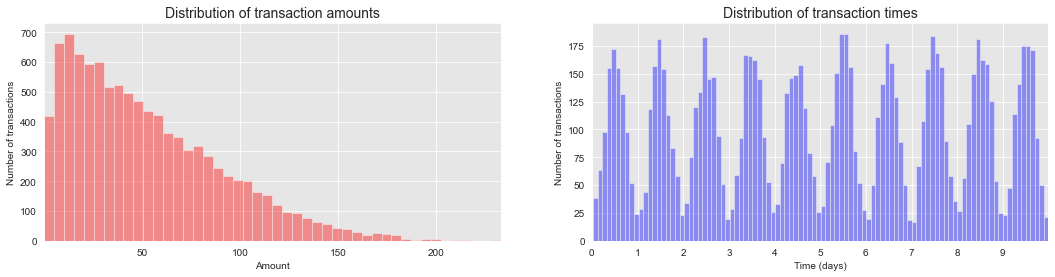

In [ ]:
distribution_amount_times_fig

La distribución de montos de transacción tiene la mayor parte de su masa para montos pequeños. La distribución de tiempos de transacción sigue una distribución gaussiana diariamente, centrada alrededor del mediodía. Estas dos distribuciones están de acuerdo con los parámetros de simulación usados en las secciones anteriores.  

(Fraud_Scenarios_Generation)=
## Generación de escenarios de fraude

Este último paso de la simulación agrega transacciones fraudulentas al conjunto de datos, usando los siguientes escenarios de fraude:

* Escenario 1: Cualquier transacción cuyo monto sea mayor a 220 es un fraude. Este escenario no está inspirado en un escenario del mundo real. Más bien, proporcionará un patrón de fraude obvio que debería ser detectado por cualquier detector de fraude baseline. Esto será útil para validar la implementación de una técnica de detección de fraude.  

* Escenario 2: Cada día, se extrae al azar una lista de dos terminales. Todas las transacciones en estos terminales en los próximos 28 días se marcarán como fraudulentas. Este escenario simula un uso criminal de un terminal, a través de phishing por ejemplo. Detectar este escenario será posible agregando características que rastreen el número de transacciones fraudulentas en el terminal. Dado que el terminal solo está comprometido por 28 días, se necesitarán diseñar estrategias adicionales que involucren deriva de concepto para lidiar eficientemente con este escenario.     

* Escenario 3: Cada día, se extrae al azar una lista de 3 clientes. En los próximos 14 días, 1/3 de sus transacciones tienen sus montos multiplicados por 5 y marcados como fraudulentas. Este escenario simula un fraude de tarjeta no presente donde las credenciales de un cliente han sido filtradas. El cliente continúa haciendo transacciones, y transacciones de valores más altos son hechas por el estafador que intenta maximizar sus ganancias. Detectar este escenario requerirá agregar características que rastreen los hábitos de gasto del cliente. Como en el escenario 2, dado que la tarjeta solo está temporalmente comprometida, también se deberían diseñar estrategias adicionales que involucren deriva de concepto. 



In [ ]:
def add_frauds(customer_profiles_table, terminal_profiles_table, transactions_df):
    
    # Por defecto, todas las transacciones son genuinas
    transactions_df['TX_FRAUD']=0
    transactions_df['TX_FRAUD_SCENARIO']=0
    
    # Scenario 1
    transactions_df.loc[transactions_df.TX_AMOUNT>220, 'TX_FRAUD']=1
    transactions_df.loc[transactions_df.TX_AMOUNT>220, 'TX_FRAUD_SCENARIO']=1
    nb_frauds_scenario_1=transactions_df.TX_FRAUD.sum()
    print("Number of frauds from scenario 1: "+str(nb_frauds_scenario_1))
    
    # Scenario 2
    for day in range(transactions_df.TX_TIME_DAYS.max()):
        
        compromised_terminals = terminal_profiles_table.TERMINAL_ID.sample(n=2, random_state=day)
        
        compromised_transactions=transactions_df[(transactions_df.TX_TIME_DAYS>=day) & 
                                                    (transactions_df.TX_TIME_DAYS<day+28) & 
                                                    (transactions_df.TERMINAL_ID.isin(compromised_terminals))]
                            
        transactions_df.loc[compromised_transactions.index,'TX_FRAUD']=1
        transactions_df.loc[compromised_transactions.index,'TX_FRAUD_SCENARIO']=2
    
    nb_frauds_scenario_2=transactions_df.TX_FRAUD.sum()-nb_frauds_scenario_1
    print("Number of frauds from scenario 2: "+str(nb_frauds_scenario_2))
    
    # Scenario 3
    for day in range(transactions_df.TX_TIME_DAYS.max()):
        
        compromised_customers = customer_profiles_table.CUSTOMER_ID.sample(n=3, random_state=day).values
        
        compromised_transactions=transactions_df[(transactions_df.TX_TIME_DAYS>=day) & 
                                                    (transactions_df.TX_TIME_DAYS<day+14) & 
                                                    (transactions_df.CUSTOMER_ID.isin(compromised_customers))]
        
        nb_compromised_transactions=len(compromised_transactions)
        
        
        random.seed(day)
        index_fauds = random.sample(list(compromised_transactions.index.values),k=int(nb_compromised_transactions/3))
        
        transactions_df.loc[index_fauds,'TX_AMOUNT']=transactions_df.loc[index_fauds,'TX_AMOUNT']*5
        transactions_df.loc[index_fauds,'TX_FRAUD']=1
        transactions_df.loc[index_fauds,'TX_FRAUD_SCENARIO']=3
        
                             
    nb_frauds_scenario_3=transactions_df.TX_FRAUD.sum()-nb_frauds_scenario_2-nb_frauds_scenario_1
    print("Number of frauds from scenario 3: "+str(nb_frauds_scenario_3))
    
    return transactions_df                 



Agreguemos transacciones fraudulentas usando estos escenarios:

In [ ]:
# %time transactions_df = add_frauds(customer_profiles_table, terminal_profiles_table, transactions_df)

Number of frauds from scenario 1: 978
Number of frauds from scenario 2: 9099
Number of frauds from scenario 3: 4604
CPU times: user 1min 14s, sys: 210 ms, total: 1min 14s
Wall time: 1min 15s


Percentage of fraudulent transactions:

In [ ]:
transactions_df.TX_FRAUD.mean()

0.008369271814634397

Number of fraudulent transactions:

In [ ]:
transactions_df.TX_FRAUD.sum()

14681

Un total de 14681 transacciones fueron marcadas como fraudulentas. Esto representa el 0.8% de las transacciones. Tenga en cuenta que la suma de los fraudes para cada escenario no es igual a la cantidad total de transacciones fraudulentas. Esto es porque las mismas transacciones pueden haber sido marcadas como fraudulentas por dos o más escenarios de fraude.  

Nuestro conjunto de datos de transacciones simulado ahora está completo, con una etiqueta fraudulenta agregada a todas las transacciones.

In [ ]:
transactions_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [ ]:
transactions_df[transactions_df.TX_FRAUD_SCENARIO==1].shape

(973, 9)

In [ ]:
transactions_df[transactions_df.TX_FRAUD_SCENARIO==2].shape

(9077, 9)

In [ ]:
transactions_df[transactions_df.TX_FRAUD_SCENARIO==3].shape

(4631, 9)

Verifiquemos cómo varían el número de transacciones, el número de transacciones fraudulentas, y el número de tarjetas comprometidas diariamente. 

In [ ]:
def get_stats(transactions_df):
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraud_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_fraudcard_per_day=transactions_df[transactions_df['TX_FRAUD']>0].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    return (nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)

(nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)=get_stats(transactions_df)

n_days=len(nb_tx_per_day)
tx_stats=pd.DataFrame({"value":pd.concat([nb_tx_per_day/50,nb_fraud_per_day,nb_fraudcard_per_day])})
tx_stats['stat_type']=["nb_tx_per_day"]*n_days+["nb_fraud_per_day"]*n_days+["nb_fraudcard_per_day"]*n_days
tx_stats=tx_stats.reset_index()

In [ ]:
# %%capture
# 
# sns.set(style='darkgrid')
# sns.set(font_scale=1.4)
# 
# fraud_and_transactions_stats_fig = plt.gcf()
# 
# fraud_and_transactions_stats_fig.set_size_inches(15, 8)
# 
# sns_plot = sns.lineplot(x="TX_TIME_DAYS", y="value", data=tx_stats, hue="stat_type", hue_order=["nb_tx_per_day","nb_fraud_per_day","nb_fraudcard_per_day"], legend=False)
# 
# sns_plot.set_title('Total transactions, and number of fraudulent transactions \n and number of compromised cards per day', fontsize=20)
# sns_plot.set(xlabel = "Number of days since beginning of data generation", ylabel="Number")
# 
# sns_plot.set_ylim([0,300])
# 
# labels_legend = ["# transactions per day (/50)", "# fraudulent txs per day", "# fraudulent cards per day"]
# 
# sns_plot.legend(loc='upper left', labels=labels_legend,bbox_to_anchor=(1.05, 1), fontsize=15)
# 


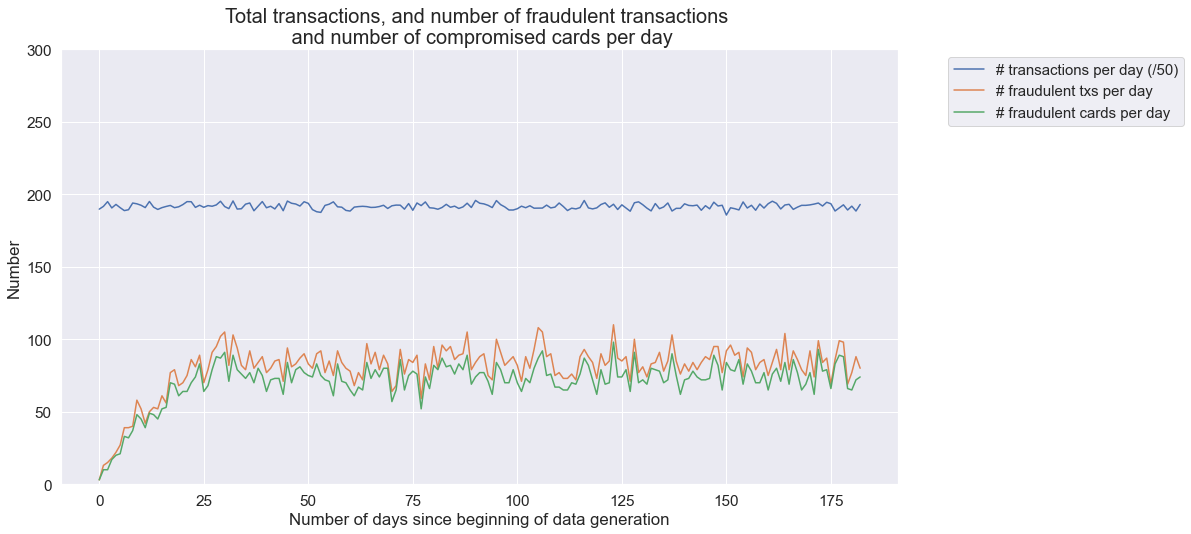

In [ ]:
fraud_and_transactions_stats_fig

Esta simulación generó alrededor de 10000 transacciones por día. El número de transacciones fraudulentas por día es alrededor de 85, y el número de tarjetas fraudulentas alrededor de 80. Vale la pena notar que el primer mes tiene un número menor de transacciones fraudulentas, lo cual se debe al hecho de que los fraudes de los escenarios 2 y 3 abarcan períodos de 28 y 14 días, respectivamente. 

El conjunto de datos resultante es interesante: Presenta desequilibrio de clases (menos del 1% de transacciones fraudulentas), una mezcla de características numéricas y categóricas, relaciones no triviales entre características, y escenarios de fraude dependientes del tiempo.

Guardemos finalmente el conjunto de datos para reutilización en el resto de este libro.

## Guardado del conjunto de datos

En lugar de guardar todo el conjunto de datos de transacciones, dividimos el conjunto de datos en lotes diarios. Esto permitirá más tarde la carga de períodos específicos en lugar de todo el conjunto de datos. Se usa el formato pickle, en lugar de CSV, para acelerar los tiempos de carga. Todos los archivos se guardan en la carpeta `DIR_OUTPUT`. Los nombres de los archivos son las fechas, con la extensión `.pkl`.

In [ ]:
DIR_OUTPUT = "./simulated-data-raw/"

if not os.path.exists(DIR_OUTPUT):
    os.makedirs(DIR_OUTPUT)

start_date = datetime.datetime.strptime("2018-04-01", "%Y-%m-%d")

for day in range(transactions_df.TX_TIME_DAYS.max()+1):
    
    transactions_day = transactions_df[transactions_df.TX_TIME_DAYS==day].sort_values('TX_TIME_SECONDS')
    
    date = start_date + datetime.timedelta(days=day)
    filename_output = date.strftime("%Y-%m-%d")+'.pkl'
    
    # Protocol=4 required for Google Colab
    transactions_day.to_pickle(DIR_OUTPUT+filename_output, protocol=4)

El conjunto de datos generado también está disponible desde Github en `https://github.com/Fraud-Detection-Handbook/simulated-data-raw`.


---

## Transformación de Características Baseline


(Baseline_Feature_Transformation)=
# Transformación de características baseline

El conjunto de datos simulado generado en la sección anterior es simple. Solo contiene las características esenciales que caracterizan una transacción con tarjeta de pago. Estas son: un identificador único para la transacción, la fecha y hora de la transacción, el monto de la transacción, un identificador único para el cliente, un número único para el comerciante, y una variable binaria que etiqueta la transacción como legítima o fraudulenta (0 para legítima o 1 para fraudulenta). La Fig. 1 proporciona las primeras tres filas del conjunto de datos simulado:
 
![alt text](images/tx_table.png)
<p style="text-align: center;">
Fig. 1. Las primeras tres transacciones en el conjunto de datos simulado usado en este capítulo.
</p>



Lo que cada fila esencialmente resume es que, a las 00:00:31, el 1 de abril de 2018, un cliente con ID 596 hizo un pago de un valor de 57.19 a un comerciante con ID 3156, y que la transacción no fue fraudulenta. Luego, a las 00:02:10, el 1 de abril de 2018, un cliente con ID 4961 hizo un pago de un valor de 81.51 a un comerciante con ID 3412, y que la transacción no fue fraudulenta. Y así sucesivamente. El conjunto de datos simulado es una larga lista de tales transacciones (1.8 millones en total). La variable `transaction_ID` es un identificador único para cada transacción.  

Aunque conceptualmente simple para un humano, tal conjunto de características sin embargo no es apropiado para un modelo predictivo de aprendizaje automático. Los algoritmos de aprendizaje automático típicamente requieren características *numéricas* y *ordenadas*. Numérico significa que el tipo de la variable debe ser un entero o un número real. Ordenado significa que el orden de los valores de una variable es significativo. 

En este conjunto de datos, las únicas características numéricas y ordenadas son el monto de la transacción y la etiqueta de fraude. La fecha es un timestamp de pandas, y por lo tanto no es numérica. Los identificadores para las transacciones, clientes, y terminales son numéricos pero no ordenados: no tendría sentido asumir por ejemplo que el terminal con ID 3548 es 'más grande' o 'mayor' que el terminal con ID 1983. Más bien, estos identificadores representan 'entidades' distintas, que se refieren como características *categóricas*. 

Desafortunadamente no hay un procedimiento estándar para lidiar con características no numéricas o categóricas. El tema se conoce en la literatura de aprendizaje automático como *ingeniería de características* o *transformación de características*. En esencia, el objetivo de la ingeniería de características es diseñar nuevas características que se asumen relevantes para un problema predictivo. El diseño de estas características usualmente depende del problema, e involucra conocimiento del dominio.

En esta sección, implementaremos tres tipos de transformación de características que se sabe que son relevantes para la detección de fraude con tarjeta de pago.

![encoding](images/encoding_variables.png)

El primer tipo de transformación involucra la variable de fecha/hora, y consiste en crear características binarias que caracterizan períodos potencialmente relevantes. Crearemos dos de estas características. La primera caracterizará si una transacción ocurre durante un día laboral o durante el fin de semana. La segunda caracterizará si una transacción ocurre durante el día o durante la noche. Estas características pueden ser útiles ya que se ha observado en conjuntos de datos del mundo real que los patrones fraudulentos difieren entre días laborales y fines de semana, y entre el día y la noche.  

El segundo tipo de transformación involucra el ID del cliente y consiste en crear características que caracterizan los comportamientos de gasto del cliente. Seguiremos el marco RFM (Recency, Frequency, Monetary value) propuesto en {cite}`VANVLASSELAER201538`, y rastrearemos el monto promedio de gasto y el número de transacciones para cada cliente y para tres tamaños de ventana. Esto llevará a la creación de seis nuevas características.

El tercer tipo de transformación involucra el ID del terminal y consiste en crear nuevas características que caracterizan el 'riesgo' asociado con el terminal. El riesgo se definirá como el número promedio de fraudes que se observaron en el terminal para tres tamaños de ventana. Esto llevará a la creación de tres nuevas características. 

La tabla a continuación resume los tipos de transformación que se realizarán y las nuevas características que se crearán. 

|Original feature name|Original feature type|Transformation|Number of new features|New feature(s) type|
|---|---|---|---|---|
|TX\_DATE\_TIME | Panda timestamp |0 si la transacción ocurre durante un día laboral, 1 si la transacción ocurre durante el fin de semana. La nueva característica se llama TX_DURING_WEEKEND.|1|Integer (0/1)|
|TX\_DATE\_TIME | Panda timestamp |0 si la transacción ocurre entre las 6am y las 0pm, 1 si la transacción ocurre entre las 0pm y las 6am. La nueva característica se llama TX_DURING_NIGHT.|1|Integer (0/1)|
|CUSTOMER\_ID | Variable categórica |Número de transacciones del cliente en los últimos n día(s), para n en {1,7,30}. Las nuevas características se llaman CUSTOMER_ID_NB_TX_nDAY_WINDOW.|3|Integer|
|CUSTOMER\_ID | Variable categórica |Monto promedio de gasto en los últimos n día(s), para n en {1,7,30}. Las nuevas características se llaman CUSTOMER_ID_AVG_AMOUNT_nDAY_WINDOW.|3|Real|
|TERMINAL\_ID | Variable categórica |Número de transacciones en el terminal en los últimos n+d día(s), para n en {1,7,30} y d=7. El parámetro d se llama retraso y se discutirá más adelante en este cuaderno. Las nuevas características se llaman TERMINAL_ID_NB_TX_nDAY_WINDOW.|3|Integer|
|TERMINAL\_ID | Variable categórica |Número promedio de fraudes en el terminal en los últimos n+d día(s), para n en {1,7,30} y d=7. El parámetro d se llama retraso y se discutirá más adelante en este cuaderno. Las nuevas características se llaman TERMINAL_ID_RISK_nDAY_WINDOW.|3|Real|

Las siguientes secciones proporcionan la implementación para cada una de estas tres transformaciones. Después de las transformaciones, se creará un conjunto de 14 nuevas características. Tenga en cuenta que algunas de las características son el resultado de funciones de agregación sobre los valores de otras características o condiciones (mismo cliente, ventana de tiempo dada). Estas características a menudo se denominan *características agregadas*.

In [ ]:
# Inicialización: Cargar funciones compartidas y datos simulados 

# Cargar funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Obtener datos simulados del repositorio de Github
if not os.path.exists("simulated-data-raw"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-raw
        

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 31567  100 31567    0     0   135k      0 --:--:-- --:--:-- --:--:--  135k
Cloning into 'simulated-data-raw'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (187/187), done.
remote: Total 189 (delta 0), reused 186 (delta 0), pack-reused 0
Receiving objects: 100% (189/189), 28.04 MiB | 3.13 MiB/s, done.


## Carga del conjunto de datos

Carguemos primero los datos de transacciones simulados en el cuaderno anterior. Cargaremos los archivos de transacciones de abril a septiembre. Los archivos se pueden cargar usando la función `read_from_files` en las [funciones compartidas](shared_functions) notebook. La función fue puesta en este cuaderno ya que se usará frecuentemente a lo largo de este libro.

La función toma como entrada la carpeta donde se ubican los archivos de datos, y las fechas que definen el período a cargar (entre `BEGIN_DATE` y `END_DATE`). Retorna un DataFrame de transacciones. Las transacciones están ordenadas por orden cronológico. 


In [ ]:
DIR_INPUT='./simulated-data-raw/data/' 

BEGIN_DATE = "2018-04-01"
END_DATE = "2018-09-30"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


Load  files
CPU times: user 3.1 s, sys: 696 ms, total: 3.79 s
Wall time: 4.13 s
1754155 transactions loaded, containing 14681 fraudulent transactions


In [ ]:
transactions_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


## Transformaciones de fecha y hora

Crearemos dos nuevas características binarias a partir de las fechas y horas de las transacciones:

* La primera caracterizará si una transacción ocurre durante un día laboral (valor 0) o un fin de semana (1), y se llamará `TX_DURING_WEEKEND`
* La segunda caracterizará si una transacción ocurre durante el día (0) o durante la noche (1). La noche se define como las horas que están entre las 0pm y las 6am. Se llamará `TX_DURING_NIGHT`. 

Para la característica `TX_DURING_WEEKEND`, definimos una función `is_weekend` que toma como entrada un timestamp de Panda, y retorna 1 si la fecha es durante un fin de semana, o 0 en caso contrario. El objeto timestamp convenientemente proporciona la función `weekday` para ayudar en el cálculo de este valor.

In [ ]:
def is_weekend(tx_datetime):
    
    # Transform date into weekday (0 is Monday, 6 is Sunday)
    weekday = tx_datetime.weekday()
    # Binary value: 0 if weekday, 1 if weekend
    is_weekend = weekday>=5
    
    return int(is_weekend)


Es entonces sencillo calcular esta característica para todas las transacciones usando la función `apply` de pandas. 

In [ ]:
# %time transactions_df['TX_DURING_WEEKEND']=transactions_df.TX_DATETIME.apply(is_weekend)

CPU times: user 7.54 s, sys: 247 ms, total: 7.79 s
Wall time: 7.94 s


Seguimos la misma lógica para implementar la característica `TX_DURING_NIGHT`. Primero, una función `is_night` que toma como entrada un timestamp de pandas, y retorna 1 si la hora es durante la noche, o 0 en caso contrario. El objeto timestamp convenientemente proporciona la propiedad `hour` para ayudar en el cálculo de este valor.

In [ ]:
def is_night(tx_datetime):
    
    # Obtener la hora de la transacción
    tx_hour = tx_datetime.hour
    # Valor binario: 1 si la hora es menor que 6, y 0 en caso contrario
    is_night = tx_hour<=6
    
    return int(is_night)

In [ ]:
# %time transactions_df['TX_DURING_NIGHT']=transactions_df.TX_DATETIME.apply(is_night)

CPU times: user 7.09 s, sys: 221 ms, total: 7.31 s
Wall time: 7.47 s


Verifiquemos que estas características fueron calculadas correctamente.

In [ ]:
transactions_df[transactions_df.TX_TIME_DAYS>=30]

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT
288062,288062,2018-05-01 00:01:21,3546,2944,18.71,2592081,30,0,0,0,1
288063,288063,2018-05-01 00:01:48,206,3521,18.60,2592108,30,0,0,0,1
288064,288064,2018-05-01 00:02:22,2610,4470,66.67,2592142,30,0,0,0,1
288065,288065,2018-05-01 00:03:15,4578,1520,79.41,2592195,30,0,0,0,1
288066,288066,2018-05-01 00:03:51,1246,7809,52.08,2592231,30,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,1,0
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,1,0
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,1,0
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,1,0


El 2018-05-01 fue un lunes, y el 2018-09-30 un domingo. Estas fechas están correctamente marcadas como día laboral, y fin de semana, respectivamente. La característica de día y noche también está correctamente establecida para las primeras transacciones, que ocurren poco después de las 0 pm, y las últimas transacciones que ocurren poco antes de las 0 pm. 

## Transformaciones de ID de cliente

Procedamos ahora con las transformaciones de ID de cliente. Tomaremos inspiración del marco RFM (Recency, Frequency, Monetary value) propuesto en {cite}`VANVLASSELAER201538`, y calcularemos dos de estas características sobre tres ventanas de tiempo. La primera característica será el número de transacciones que ocurren dentro de una ventana de tiempo (Frecuencia). La segunda será el monto promedio gastado en estas transacciones (Valor monetario). Las ventanas de tiempo se establecerán en uno, siete, y treinta días. Esto generará seis nuevas características. Tenga en cuenta que estas ventanas de tiempo podrían optimizarse más tarde junto con los modelos usando un procedimiento de selección de modelos ([Capítulo 5](Model_Selection)). 

Implementemos estas transformaciones escribiendo una función `get_customer_spending_behaviour_features`. La función toma como entradas el conjunto de transacciones para un cliente y un conjunto de tamaños de ventana. Retorna un DataFrame con las seis nuevas características. Nuestra implementación se basa en la función `rolling` de pandas, que facilita el cálculo de agregados sobre una ventana de tiempo.


In [ ]:
def get_customer_spending_behaviour_features(customer_transactions, windows_size_in_days=[1,7,30]):
    
    # Primero ordenemos las transacciones cronológicamente
    customer_transactions=customer_transactions.sort_values('TX_DATETIME')
    
    # La fecha y hora de la transacción se establece como el índice, lo que permitirá el uso de la función rolling 
    customer_transactions.index=customer_transactions.TX_DATETIME
    
    # Para cada tamaño de ventana
    for window_size in windows_size_in_days:
        
        # Calcular la suma de los montos de transacción y el número de transacciones para el tamaño de ventana dado
        SUM_AMOUNT_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').sum()
        NB_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').count()
    
        # Calcular el monto promedio de transacción para el tamaño de ventana dado
        # NB_TX_WINDOW siempre es >0 ya que la transacción actual siempre está incluida
        AVG_AMOUNT_TX_WINDOW=SUM_AMOUNT_TX_WINDOW/NB_TX_WINDOW
    
        # Guardar valores de características
        customer_transactions['CUSTOMER_ID_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        customer_transactions['CUSTOMER_ID_AVG_AMOUNT_'+str(window_size)+'DAY_WINDOW']=list(AVG_AMOUNT_TX_WINDOW)
    
    # Reindexar según los IDs de transacción
    customer_transactions.index=customer_transactions.TRANSACTION_ID
        
    # Y retornar el dataframe con las nuevas características
    return customer_transactions


Calculemos estos agregados para el primer cliente.

In [ ]:
spending_behaviour_customer_0=get_customer_spending_behaviour_features(transactions_df[transactions_df.CUSTOMER_ID==0])
spending_behaviour_customer_0

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT,CUSTOMER_ID_NB_TX_1DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW
TRANSACTION_ID,,,,,,,,,,,,,,,,,
1758,1758,2018-04-01 07:19:05,0,6076,123.59,26345,0,0,0,1,0,1.0,123.590000,1.0,123.590000,1.0,123.590000
8275,8275,2018-04-01 18:00:16,0,858,77.34,64816,0,0,0,1,0,2.0,100.465000,2.0,100.465000,2.0,100.465000
8640,8640,2018-04-01 19:02:02,0,6698,46.51,68522,0,0,0,1,0,3.0,82.480000,3.0,82.480000,3.0,82.480000
12169,12169,2018-04-02 08:51:06,0,6569,54.72,118266,1,0,0,0,0,3.0,59.523333,4.0,75.540000,4.0,75.540000
15764,15764,2018-04-02 14:05:38,0,7707,63.30,137138,1,0,0,0,0,4.0,60.467500,5.0,73.092000,5.0,73.092000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750390,1750390,2018-09-30 13:38:41,0,3096,38.23,15773921,182,0,0,1,0,5.0,64.388000,28.0,57.306429,89.0,63.097640
1750758,1750758,2018-09-30 14:10:21,0,9441,43.60,15775821,182,0,0,1,0,6.0,60.923333,29.0,56.833793,89.0,62.433933
1751039,1751039,2018-09-30 14:34:30,0,1138,69.69,15777270,182,0,0,1,0,7.0,62.175714,29.0,57.872414,90.0,62.514556


Podemos verificar que las nuevas características son consistentes con el perfil del cliente (ver el cuaderno anterior). Para el cliente 0, el monto medio era `mean_amount`=62.26, y la frecuencia de transacciones era `mean_nb_tx_per_day`=2.18. Estos valores están efectivamente estrechamente emparejados por las características `CUSTOMER_ID_NB_TX_30DAY_WINDOW` y `CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW`, especialmente después de 30 días.

Generemos ahora estas características para todos los clientes. Esto es sencillo usando los métodos `groupby` y `apply` de pandas.

In [ ]:
# %time transactions_df=transactions_df.groupby('CUSTOMER_ID').apply(lambda x: get_customer_spending_behaviour_features(x, windows_size_in_days=[1,7,30]))
# transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)


CPU times: user 1min 2s, sys: 1.21 s, total: 1min 3s
Wall time: 1min 7s


In [ ]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT,CUSTOMER_ID_NB_TX_1DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,1,1,1.0,57.160000,1.0,57.160000,1.0,57.160000
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,1,1,1.0,81.510000,1.0,81.510000,1.0,81.510000
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,1,1,1.0,146.000000,1.0,146.000000,1.0,146.000000
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0,1,1,1.0,64.490000,1.0,64.490000,1.0,64.490000
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0,1,1,1.0,50.990000,1.0,50.990000,1.0,50.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,1,0,2.0,75.280000,12.0,67.047500,72.0,69.521111
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,1,0,1.0,1.230000,21.0,22.173810,93.0,24.780753
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,1,0,5.0,7.368000,21.0,7.400476,65.0,7.864462
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,1,0,3.0,100.696667,16.0,107.052500,51.0,102.919608


## Terminal ID transformations

Finalmente, procedamos con las transformaciones de ID de terminal. El objetivo principal será extraer una *puntuación de riesgo*, que evalúa la exposición de un ID de terminal dado a transacciones fraudulentas. La puntuación de riesgo se definirá como el número promedio de transacciones fraudulentas que ocurrieron en un ID de terminal sobre una ventana de tiempo. Como en las transformaciones de ID de cliente, usaremos tres tamaños de ventana, de 1, 7, y 30 días.

Contrario a las transformaciones de ID de cliente, las ventanas de tiempo no precederán directamente una transacción dada. En su lugar, serán desplazadas hacia atrás por un *período de retraso*. El período de retraso tiene en cuenta el hecho de que, en la práctica, las transacciones fraudulentas solo se descubren después de una investigación de fraude o una queja de cliente. Por lo tanto, las etiquetas fraudulentas, que se necesitan para calcular la puntuación de riesgo, solo están disponibles después de este período de retraso. Como primera aproximación, este período de retraso se establecerá en una semana. Las motivaciones para el período de retraso se argumentarán más adelante en [Capítulo 5, Estrategias de validación](Validation_Strategies). 

Realicemos el cálculo de las puntuaciones de riesgo definiendo una función `get_count_risk_rolling_window`. La función toma como entradas el DataFrame de transacciones para un ID de terminal dado, el período de retraso, y una lista de tamaños de ventana. En la primera etapa, se calcula el número de transacciones y transacciones fraudulentas para el período de retraso (`NB_TX_DELAY` y `NB_FRAUD_DELAY`). En la segunda etapa, se calcula el número de transacciones y transacciones fraudulentas para cada tamaño de ventana más el período de retraso (`NB_TX_DELAY_WINDOW` y `NB_FRAUD_DELAY_WINDOW`). El número de transacciones y transacciones fraudulentas que ocurrieron para un tamaño de ventana dado, desplazado hacia atrás por el período de retraso, se obtiene entonces simplemente calculando las diferencias de las cantidades obtenidas para el período de retraso, y el tamaño de ventana más el período de retraso:

```
NB_FRAUD_WINDOW=NB_FRAUD_DELAY_WINDOW-NB_FRAUD_DELAY
NB_TX_WINDOW=NB_TX_DELAY_WINDOW-NB_TX_DELAY
```

La puntuación de riesgo se obtiene finalmente calculando la proporción de transacciones fraudulentas para cada tamaño de ventana (o 0 si no ocurrió ninguna transacción para la ventana dada):

```
RISK_WINDOW=NB_FRAUD_WINDOW/NB_TX_WINDOW
```

Además de la puntuación de riesgo, la función también devuelve el número de transacciones para cada tamaño de ventana. Esto resulta en la adición de seis nuevas características: El riesgo y el número de transacciones, para tres tamaños de ventana.


In [ ]:
def get_count_risk_rolling_window(terminal_transactions, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"):
    
    terminal_transactions=terminal_transactions.sort_values('TX_DATETIME')
    
    terminal_transactions.index=terminal_transactions.TX_DATETIME
    
    NB_FRAUD_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').sum()
    NB_TX_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').count()
    
    for window_size in windows_size_in_days:
    
        NB_FRAUD_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').sum()
        NB_TX_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').count()
    
        NB_FRAUD_WINDOW=NB_FRAUD_DELAY_WINDOW-NB_FRAUD_DELAY
        NB_TX_WINDOW=NB_TX_DELAY_WINDOW-NB_TX_DELAY
    
        RISK_WINDOW=NB_FRAUD_WINDOW/NB_TX_WINDOW
        
        terminal_transactions[feature+'_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        terminal_transactions[feature+'_RISK_'+str(window_size)+'DAY_WINDOW']=list(RISK_WINDOW)
        
    terminal_transactions.index=terminal_transactions.TRANSACTION_ID
    
    # Replace NA values with 0 (all undefined risk scores where NB_TX_WINDOW is 0) 
    terminal_transactions.fillna(0,inplace=True)
    
    return terminal_transactions


In [ ]:
transactions_df[transactions_df.TX_FRAUD==1]

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT,CUSTOMER_ID_NB_TX_1DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW
3527,3527,2018-04-01 10:17:43,3774,3059,225.41,37063,0,1,1,1,0,3.0,158.073333,3.0,158.073333,3.0,158.073333
5789,5790,2018-04-01 13:31:48,4944,6050,222.26,48708,0,1,1,1,0,2.0,127.605000,2.0,127.605000,2.0,127.605000
6549,6549,2018-04-01 14:42:02,4625,9102,226.40,52922,0,1,1,1,0,4.0,167.165000,4.0,167.165000,4.0,167.165000
9583,9583,2018-04-02 01:01:05,3814,6893,59.15,90065,1,1,3,0,1,6.0,29.138333,6.0,29.138333,6.0,29.138333
10356,10355,2018-04-02 05:03:35,2513,1143,222.04,104615,1,1,1,0,1,5.0,123.740000,5.0,123.740000,5.0,123.740000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753524,1753524,2018-09-30 19:51:48,1671,3192,128.60,15796308,182,1,3,1,0,6.0,138.358333,25.0,106.957200,82.0,75.621341
1753600,1753600,2018-09-30 20:09:00,4166,632,17.39,15797340,182,1,2,1,0,3.0,19.766667,19.0,15.984737,86.0,15.846512
1753673,1753673,2018-09-30 20:30:52,4097,1558,24.04,15798652,182,1,2,1,0,3.0,23.050000,16.0,40.440625,63.0,41.877460
1754014,1754014,2018-09-30 22:27:04,100,8604,73.85,15805624,182,1,3,1,0,2.0,48.010000,26.0,30.384231,103.0,23.627184


Calculemos estas seis características para el primer ID de terminal que contiene al menos un fraude:

In [ ]:
# Obtener el primer ID de terminal que contiene fraudes
transactions_df[transactions_df.TX_FRAUD==0].TERMINAL_ID[0]

3156

In [ ]:
get_count_risk_rolling_window(transactions_df[transactions_df.TERMINAL_ID==3059], delay_period=7, windows_size_in_days=[1,7,30])

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
TRANSACTION_ID,,,,,,,,,,,,,,,,,,,,,
3527,3527,2018-04-01 10:17:43,3774,3059,225.41,37063,0,1,1,1,...,3.0,158.073333,3.0,158.073333,0.0,0.0,0.0,0.0,0.0,0.0
4732,4732,2018-04-01 11:59:14,55,3059,36.28,43154,0,0,0,1,...,2.0,35.670000,2.0,35.670000,0.0,0.0,0.0,0.0,0.0,0.0
16216,16216,2018-04-02 14:47:34,4879,3059,105.00,139654,1,0,0,0,...,10.0,76.010000,10.0,76.010000,0.0,0.0,0.0,0.0,0.0,0.0
18249,18249,2018-04-02 19:08:10,2263,3059,90.89,155290,1,0,0,0,...,7.0,50.458571,7.0,50.458571,0.0,0.0,0.0,0.0,0.0,0.0
26512,26512,2018-04-03 15:44:49,4879,3059,58.51,229489,2,0,0,0,...,14.0,71.070000,14.0,71.070000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1697944,1697944,2018-09-25 05:32:56,402,3059,57.30,15312776,177,0,0,0,...,14.0,65.167857,46.0,68.163261,1.0,0.0,9.0,0.0,36.0,0.0
1701971,1701971,2018-09-25 12:30:54,1035,3059,7.56,15337854,177,0,0,0,...,23.0,7.052174,107.0,6.763738,2.0,0.0,10.0,0.0,36.0,0.0
1704512,1704512,2018-09-25 16:37:41,1519,3059,35.79,15352661,177,0,0,0,...,7.0,41.404286,30.0,46.780000,1.0,0.0,9.0,0.0,36.0,0.0


Podemos verificar que el primer fraude ocurrió el 2018/09/10, y que las puntuaciones de riesgo solo comienzan a contarse con un retraso de una semana. 

Generemos finalmente estas características para todos los terminales. Esto es sencillo usando los métodos `groupby` y `apply` de pandas. 

In [ ]:
# %time transactions_df=transactions_df.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"))
# transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)


CPU times: user 2min 27s, sys: 2.23 s, total: 2min 29s
Wall time: 2min 41s


In [ ]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,1,...,1.0,57.160000,1.0,57.160000,0.0,0.0,0.0,0.0,0.0,0.00000
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,1,...,1.0,81.510000,1.0,81.510000,0.0,0.0,0.0,0.0,0.0,0.00000
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,1,...,1.0,146.000000,1.0,146.000000,0.0,0.0,0.0,0.0,0.0,0.00000
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0,1,...,1.0,64.490000,1.0,64.490000,0.0,0.0,0.0,0.0,0.0,0.00000
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0,1,...,1.0,50.990000,1.0,50.990000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,1,...,12.0,67.047500,72.0,69.521111,1.0,0.0,4.0,0.0,28.0,0.00000
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,1,...,21.0,22.173810,93.0,24.780753,1.0,0.0,9.0,0.0,39.0,0.00000
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,1,...,21.0,7.400476,65.0,7.864462,1.0,0.0,5.0,0.0,33.0,0.00000
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,1,...,16.0,107.052500,51.0,102.919608,1.0,0.0,6.0,0.0,28.0,0.00000


## Saving of dataset

Guardemos finalmente el conjunto de datos, dividido en lotes diarios, usando el formato pickle. 

In [ ]:
DIR_OUTPUT = "./simulated-data-transformed/"

if not os.path.exists(DIR_OUTPUT):
    os.makedirs(DIR_OUTPUT)

start_date = datetime.datetime.strptime("2018-04-01", "%Y-%m-%d")

for day in range(transactions_df.TX_TIME_DAYS.max()+1):
    
    transactions_day = transactions_df[transactions_df.TX_TIME_DAYS==day].sort_values('TX_TIME_SECONDS')
    
    date = start_date + datetime.timedelta(days=day)
    filename_output = date.strftime("%Y-%m-%d")+'.pkl'
    
    # Protocol=4 required for Google Colab
    transactions_day.to_pickle(DIR_OUTPUT+filename_output, protocol=4)

El conjunto de datos generado también está disponible en Github en `https://github.com/Fraud-Detection-Handbook/simulated-data-transformed`.


---

## Modelado Baseline


(Baseline_FDS)=
# Sistema de detección de fraude baseline

Esta sección tiene como objetivo mostrar cómo se puede diseñar un sistema simple de detección de fraude en unos pocos pasos. Usaremos los datos simulados generados en la sección anterior, y nos basaremos en un enfoque de aprendizaje supervisado como se describe en la sección {ref}`ML_For_CCFD_Baseline_Methodology` del capítulo anterior. La metodología de aprendizaje supervisado baseline se ilustra en la Fig. 1. 

![alt text](images/baseline_ML_workflow_subset.png)
<p style="text-align: center;">
Fig. 1. Metodología de aprendizaje supervisado baseline para detección de fraude con tarjeta de crédito. El área verde resalta los pasos que se implementarán en esta sección.
</p>

Por simplicidad, esta sección no abordará la parte de validación de la metodología de aprendizaje supervisado baseline. La parte de validación se cubrirá en el Capítulo 5. El diseño de nuestro sistema de detección de fraude consistirá en tres pasos principales, resaltados en verde en la Fig. 1:

1. Definir un conjunto de entrenamiento (datos históricos) y un conjunto de prueba (datos nuevos). El conjunto de entrenamiento es el subconjunto de transacciones que se usan para entrenar el modelo de predicción. El conjunto de prueba es el subconjunto de transacciones que se usan para evaluar el rendimiento del modelo de predicción.
2. Entrenar un modelo de predicción: Este paso consiste en usar el conjunto de entrenamiento para encontrar un modelo de predicción capaz de predecir si una transacción es genuina o fraudulenta. Nos basaremos para esta tarea en la biblioteca Python `sklearn`, que proporciona funciones fáciles de usar para entrenar modelos de predicción. 
3. Evaluar el rendimiento del modelo de predicción: El rendimiento del modelo de predicción se evalúa usando el conjunto de prueba (datos nuevos). 

Detallamos cada uno de estos pasos en el resto de esta sección. 

In [ ]:
# Inicialización: Cargar funciones compartidas y datos simulados 

# Cargar funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Obtener datos simulados del repositorio de Github
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63076  100 63076    0     0    99k      0 --:--:-- --:--:-- --:--:--     0:-- --:--:--   99k


(Baseline_FDS_Training_Test_Sets)=
## Definición de los conjuntos de entrenamiento y prueba

El conjunto de entrenamiento tiene como objetivo entrenar un modelo de predicción, mientras que el conjunto de prueba tiene como objetivo evaluar el rendimiento del modelo de predicción en nuevos datos. En un contexto de detección de fraude, las transacciones del conjunto de prueba ocurren cronológicamente *después* de las transacciones usadas para entrenar el modelo. 

Usaremos las transacciones del 2018-07-25 al 2018-07-31 para el conjunto de entrenamiento, y del 2018-08-08 al 2018-08-14 para el conjunto de prueba. Una semana de datos será suficiente para entrenar un primer modelo de predicción y evaluar su rendimiento. Más tarde usaremos períodos más grandes para entrenamiento y prueba para evaluar cómo los conjuntos más grandes pueden afectar los resultados de rendimiento.

Vale la pena notar que elegimos que nuestro conjunto de prueba tenga lugar una semana después de la última transacción del conjunto de entrenamiento. En un contexto de detección de fraude, este período que separa el conjunto de entrenamiento y prueba se refiere como el *período de retraso* o *retraso de retroalimentación* {cite}`dal2017credit`. Tiene en cuenta el hecho de que, en un sistema de detección de fraude del mundo real, la etiqueta de una transacción (fraudulenta o genuina) solo se conoce después de una queja del cliente, o gracias al resultado de una investigación de fraude. Por lo tanto, en un escenario realista, los datos anotados disponibles para entrenar un modelo y comenzar a hacer predicciones para un día dado son anteriores a ese día menos el período de retraso. Establecer un período de retraso de una semana es simplista. Asume que las etiquetas (fraudulentas o genuinas) para todas las transacciones se conocen exactamente una semana después de que ocurrieron. Este no es el caso en la práctica, ya que el retraso puede ser más corto cuando los clientes reportan fraudes rápidamente, o mucho más largo en casos donde los fraudes permanecen sin detectar durante meses. El período de retraso es de hecho un parámetro en la evaluación de un modelo de detección de fraude, que puede ajustarse durante la etapa de validación (ver [Capítulo 5](Validation_Strategies)). Un retraso de una semana es, en primera aproximación, una base razonable: por experiencia, las estadísticas generalmente muestran que la mayor parte de la retroalimentación está disponible después de un retraso de una semana.  

Carguemos las transacciones del 2018-07-25 al 2018-08-14, y grafiquemos el número de transacciones por día, transacciones fraudulentas por día, y tarjetas fraudulentas por día.


In [ ]:
# Load data from the 2018-07-25 to the 2018-08-14

DIR_INPUT='./simulated-data-transformed/data/' 

BEGIN_DATE = "2018-07-25"
END_DATE = "2018-08-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


Load  files
CPU times: user 48.2 ms, sys: 50.9 ms, total: 99.2 ms
Wall time: 149 ms
201295 transactions loaded, containing 1792 fraudulent transactions


In [ ]:
# Calcular el número de transacciones por día, transacciones fraudulentas por día y tarjetas fraudulentas por día

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of compromised cards per day
    nb_compromised_cards_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_cards_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats

tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")


In [ ]:
# %%capture
# 
# # Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day
# 
# def get_template_tx_stats(ax ,fs,
#                           start_date_training,
#                           title='',
#                           delta_train=7,
#                           delta_delay=7,
#                           delta_test=7,
#                           ylim=300):
#     
#     ax.set_title(title, fontsize=fs*1.5)
#     ax.set_ylim([0, ylim])
#     
#     ax.set_xlabel('Date', fontsize=fs)
#     ax.set_ylabel('Number', fontsize=fs)
#     
#     plt.yticks(fontsize=fs*0.7) 
#     plt.xticks(fontsize=fs*0.7)    
# 
#     ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
#     ax.axvline(start_date_test, 0, ylim, color="black")
#     
#     ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
#     ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
#     ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)
# 
# 
# cmap = plt.get_cmap('jet')
# colors={'nb_tx_per_day':cmap(0), 
#         'nb_fraudulent_transactions_per_day':cmap(200), 
#         'nb_compromised_cards_per_day':cmap(250)}
# 
# fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))
# 
# # Training period
# start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
# delta_train = delta_delay = delta_test = 7
# 
# end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)
# 
# # Test period
# start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
# end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)
# 
# get_template_tx_stats(ax, fs=20,
#                       start_date_training=start_date_training,
#                       title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day',
#                       delta_train=delta_train,
#                       delta_delay=delta_delay,
#                       delta_test=delta_test
#                      )
# 
# ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day']/50, 'b', color=colors['nb_tx_per_day'], label = '# transactions per day (/50)')
# ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# fraudulent txs per day')
# ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# compromised cards per day')
# 
# ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)
# 


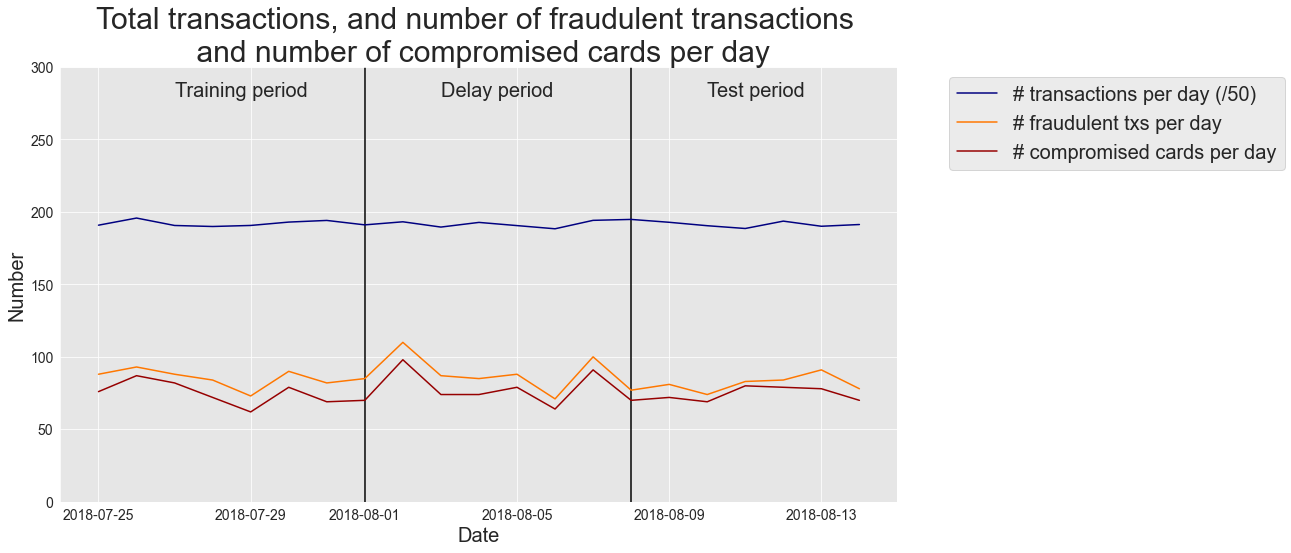

In [ ]:
fraud_and_transactions_stats_fig

El gráfico ilustra que el número de transacciones y fraudes es similar en los períodos de entrenamiento y prueba. El número promedio de fraudes es alrededor de 85 por día. Extraigamos del conjunto de datos las transacciones para el conjunto de entrenamiento y el conjunto de prueba. 

In [ ]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7):
    
    # Obtener los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtener los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtener clientes conocidos como defraudados del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtener el día inicial relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtener datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Tarjetas comprometidas de ese día de prueba, menos el período de retraso, se agregan al grupo de clientes conocidos como defraudados
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Ordenar los conjuntos de datos por orden ascendente de ID de transacción
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)

In [ ]:
(train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
                                       delta_train=7,delta_delay=7,delta_test=7)

El conjunto de entrenamiento contiene 67240 transacciones, de las cuales 598 son fraudulentas.

In [ ]:
train_df.shape

(67240, 23)

In [ ]:
train_df[train_df.TX_FRAUD==1].shape


(598, 23)

El conjunto de prueba contiene 58264 transacciones, de las cuales 385 son fraudulentas.

In [ ]:
test_df.shape

(58264, 23)

In [ ]:
test_df[test_df.TX_FRAUD==1].shape


(385, 23)

That is, a proportion of 0.007 fraudulent transactions.

In [ ]:
385/58264

0.00660785390635727

(Baseline_FDS_Decision_Tree)=
## Entrenamiento del modelo: Árbol de decisión

Como se explica en la sección {ref}`ML_For_CCFD_Baseline_Methodology`, el entrenamiento de un modelo de predicción consiste en identificar una relación matemática entre dos conjuntos de características, llamadas características de *entrada* y *salida*. En un contexto de detección de fraude, el objetivo es encontrar una función que pueda predecir si una transacción es fraudulenta o genuina (la característica de salida), usando características que caracterizan las transacciones (las características de entrada).

Definiremos las características de entrada y salida de la siguiente manera:

* La característica de salida será la etiqueta de transacción `TX_FRAUD`
* Las características de entrada serán el monto de transacción `TX_AMOUNT`, así como todas las características que se calcularon en la sección anterior, que caracterizan el contexto de una transacción.


In [ ]:
output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


En Python, el entrenamiento de un modelo de predicción se facilita usando la biblioteca `sklearn`. En particular, la biblioteca `sklearn` proporciona implementaciones para entrenar una amplia gama de modelos de predicción.  

El entrenamiento de modelos de predicción se cubrirá con más detalle en [Capítulo 5, Selección de Modelos](Model_Selection). Por ahora, simplemente nos enfocaremos en entrenar algunos clasificadores estándar, sin entrar en el detalle de cómo se realiza realmente el entrenamiento.

Comenzaremos confiando en un modelo de predicción llamado *árbol de decisión*.

Creemos una función `fit_model_and_get_predictions` que entrena un modelo y retorna predicciones para un conjunto de prueba. La función toma como entrada un objeto clasificador de `sklearn` (un modelo de predicción de `sklearn`), un conjunto de entrenamiento, un conjunto de prueba, y el conjunto de características de entrada y salida. El conjunto de entrenamiento se usará para entrenar el clasificador. Esto se hace llamando al método `fit` del objeto clasificador de `sklearn`. Las predicciones del clasificador para los conjuntos de entrenamiento y prueba se obtienen entonces llamando al método `predict_proba` del objeto clasificador de `sklearn` (cf. [Capítulo 4](Threshold_Based_Metrics)).

La función retorna un diccionario que contiene el clasificador entrenado, las predicciones para el conjunto de entrenamiento, las predicciones para el conjunto de prueba, y los tiempos de ejecución para entrenamiento e inferencia.

In [ ]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # Por defecto, escala los datos de entrada
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # Primero entrenamos el clasificador usando el método `fit`, y pasamos como argumentos las características de entrada y salida
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # Luego obtenemos las predicciones en los datos de entrenamiento y prueba usando el método `predict_proba`
    # Las predicciones se devuelven como un array de numpy, que proporciona la probabilidad de fraude para cada transacción 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # El resultado se devuelve como un diccionario que contiene los modelos ajustados, 
    # y las predicciones en los conjuntos de entrenamiento y prueba
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

Como ejemplo, entrenemos un pequeño árbol de decisión (con una profundidad máxima de 2). Primero creamos un objeto de árbol de decisión (`sklearn.tree.DecisionTreeClassifier`), y llamamos a `fit_model_and_get_predictions_dictionary` para entrenar el árbol de decisión, y obtener las predicciones en los conjuntos de entrenamiento y prueba. 

In [ ]:
# Primero creamos un objeto de árbol de decisión. Limitaremos su profundidad a 2 para interpretabilidad, 
# y estableceremos el estado aleatorio en cero para reproducibilidad
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                 input_features, output_feature,
                                                                 scale=False)

Veamos las predicciones obtenidas para las primeras cinco transacciones del conjunto de prueba:

In [ ]:
test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
test_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW,TX_FRAUD_PREDICTED
134215,1236698,2018-08-08 00:01:14,2765,2747,42.32,11145674,129,0,0,0,...,67.468529,120.0,64.611750,2.0,0.0,9.0,0.0,31.0,0.000000,0.003536
134216,1236699,2018-08-08 00:02:33,714,2073,108.19,11145753,129,0,0,0,...,79.955455,124.0,85.365645,2.0,0.0,10.0,0.0,23.0,0.000000,0.003536
134218,1236701,2018-08-08 00:08:40,4982,1258,26.13,11146120,129,0,0,0,...,56.269167,61.0,49.095902,1.0,0.0,10.0,0.0,26.0,0.076923,0.003536
134219,1236702,2018-08-08 00:08:41,704,8501,65.81,11146121,129,0,0,0,...,62.643333,11.0,63.287273,1.0,0.0,6.0,0.0,23.0,0.000000,0.003536
134220,1236703,2018-08-08 00:10:34,3085,4208,55.22,11146234,129,0,0,0,...,71.993846,72.0,59.899306,1.0,0.0,5.0,0.0,21.0,0.523810,0.003536


La probabilidad de fraude para todas estas transacciones es de 0.003536. Podemos mostrar el árbol de decisión para entender cómo se establecieron estas probabilidades:

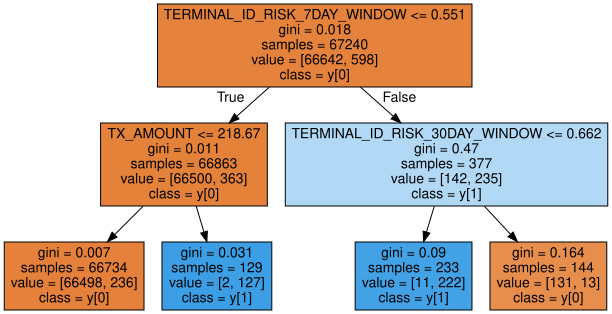

In [ ]:
display(graphviz.Source(sklearn.tree.export_graphviz(classifier,feature_names=input_features,class_names=True, filled=True)))

Un árbol de decisión permite dividir el espacio de entrada en diferentes regiones, de tal manera que las transacciones fraudulentas se separan de las transacciones genuinas. El último nivel del árbol (las hojas) da el número de transacciones de entrenamiento fraudulentas y genuinas en cada una de estas regiones. El color indica si un nodo o hoja del árbol contiene una mayoría de transacciones genuinas (naranja) o fraudulentas (azul).

Cada una de las cinco primeras transacciones cae en la primera hoja, una región que contiene 236 transacciones fraudulentas y 66498 transacciones genuinas, es decir, una región donde la probabilidad de fraude es $\frac{236}{66498+236}=0.003536$.

Vale la pena notar que el árbol de decisión encontró correctamente que las transacciones con un monto alto son fraudes (escenario 1 en el [proceso de generación de fraude](Fraud_Scenarios_Generation)). La región correspondiente es la segunda hoja. Sin embargo, el umbral de decisión (218.67) no se encontró de manera óptima, ya que la segunda hoja contiene 2 transacciones genuinas mal clasificadas. El umbral óptimo debería ser 220, como se define en el escenario 1, pero solo se ajustó empíricamente a partir de los datos de entrenamiento que representan una muestra de la distribución general de datos.

## Evaluación del rendimiento

Evaluemos finalmente el rendimiento de este modelo de árbol de decisión. Calcularemos tres métricas de rendimiento: El AUC ROC, Average Precision (AP), y Card Precision top-$k$ (CP@k). La motivación para estas tres métricas se cubrirá en [Capítulo 4](Performance_Metrics). Por ahora, es suficiente saber que:

* El Card Precision top-$k$ es la medida más pragmática e interpretable. Tiene en cuenta el hecho de que los investigadores solo pueden verificar un máximo de $k$ tarjetas potencialmente fraudulentas por día. Se calcula clasificando, para cada día en el conjunto de prueba, las transacciones más fraudulentas, y seleccionando las $k$ tarjetas cuyas transacciones tienen las probabilidades de fraude más altas. La precisión (proporción de tarjetas realmente comprometidas de las tarjetas comprometidas predichas) se calcula entonces para cada día. El Card Precision top-$k$ es el promedio de estas precisiones diarias. El número $k$ se establecerá en $100$ (es decir, se asume que solo se pueden verificar 100 tarjetas cada día). La métrica se describe en detalle en [Capítulo 4, Métricas Precision top-k](Precision_Top_K_Metrics).
* El Average Precision es un proxy para el Card Precision top-$k$, que integra precisiones para todos los valores posibles de $k$. La métrica se describe en detalle en [Capítulo 4, Curva Precision-Recall](Precision_Recall_Curve).
* El AUC ROC es una medida alternativa al Average Precision, que da más importancia a las puntuaciones obtenidas con valores de $k$ más altos. Es menos relevante en la práctica ya que los rendimientos que más importan son aquellos para valores bajos de $k$. Sin embargo, también lo reportamos ya que es la métrica de rendimiento más ampliamente usada para detección de fraude en la literatura. La métrica se describe en detalle en [Capítulo 4, Curva de Característica Operativa del Receptor (ROC)](Receiving_Operating_Characteristic_Curve).

Tenga en cuenta que las tres métricas proporcionan valores en el intervalo $[0,1]$, y que valores más altos significan mejores rendimientos. 

Proporcionamos la implementación a continuación para calcular estas tres métricas de rendimiento. Los detalles de su implementación se cubrirán en [Capítulo 4](Performance_Metrics).


In [ ]:
def card_precision_top_k_day(df_day,top_k):
    
    # Esto toma el máximo de las predicciones Y el máximo de la etiqueta TX_FRAUD para cada CUSTOMER_ID, 
    # y ordena por orden decreciente de predicción fraudulenta
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Obtener las k tarjetas más sospechosas
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Calcular precisión top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k

def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Ordenar días por orden creciente
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # Al principio, la lista de tarjetas comprometidas detectadas está vacía
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # Para cada día, calcular precisión top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Eliminemos las tarjetas comprometidas detectadas del conjunto de transacciones diarias
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Actualicemos la lista de tarjetas comprometidas detectadas
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Calcular la media
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Retorna la precisión top k por día como una lista, y la media resultante
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k

def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances

Calculemos el rendimiento en términos de AUC ROC, Precisión Promedio (AP), y Precisión de Tarjeta top 100 (CP@100) para el árbol de decisión.

In [ ]:
predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.763,0.496,0.241


La métrica más interpretable es la Precisión de Tarjeta@100, que nos dice que cada día, el 24% de las tarjetas con las puntuaciones fraudulentas más altas estaban efectivamente comprometidas. Dado que el porcentaje de fraudes en el conjunto de prueba es del 0.7%, esta proporción de fraudes detectados es alta y significa que el clasificador efectivamente logra hacer mucho mejor que el azar. 

La interpretación del AUC ROC y la Precisión Promedio es menos directa. Sin embargo, por definición, se sabe que un clasificador aleatorio daría un AUC ROC de 0.5, y una Precisión Promedio de 0.007 (la proporción de fraudes en el conjunto de prueba). Los valores obtenidos son mucho más altos (0.764) y (0.496), confirmando la capacidad del clasificador para proporcionar predicciones mucho mejores que un modelo aleatorio.

Nota: Los rendimientos para un modelo aleatorio se pueden calcular simplemente estableciendo todas las predicciones a una probabilidad de $0.5$:


In [ ]:
predictions_df['predictions']=0.5
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.5,0.007,0.017


(Baseline_FDS_Performances_Simulation)=
## Performances using standard prediction models

Ahora tenemos todos los bloques de construcción para entrenar y evaluar otros clasificadores. Además del árbol de decisión con profundidad 2, entrenemos otros cuatro modelos de predicción: un *árbol de decisión* con profundidad ilimitada, un modelo de *regresión logística*, un *bosque aleatorio*, y un modelo de boosting (consulte la celda de importación para detalles de la biblioteca). Estos modelos son los más comúnmente usados en benchmarks en la literatura de detección de fraude {cite}`yousefi2019comprehensive,priscilla2019credit`. 
 
Para este propósito, creemos primero un diccionario de clasificadores de `sklearn` que instancia cada uno de estos clasificadores. Luego entrenamos y calculamos las predicciones para cada uno de estos clasificadores usando la función `fit_model_and_get_predictions`.

In [ ]:
classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0), 
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0), 
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0), 
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                        'XGBoost':xgboost.XGBClassifier(random_state=0,n_jobs=-1),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:
    
    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df, 
                                                                                  input_features=input_features,
                                                                                output_feature=output_feature)
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions


[11:36:54] WARNING: /private/var/folders/2y/mv3z1v0945b60_l2bzjwpzj80000gn/T/pip-install-v081hmhv/xgboost_5f8c79180547427599a229ec66faab67/build/temp.macosx-10.9-x86_64-3.9/xgboost/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


Evaluemos finalmente los rendimientos de predicción de estos cinco modelos, en el conjunto de prueba y el conjunto de entrenamiento, y sus tiempos de ejecución.

In [ ]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

In [ ]:
# performances on test set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df, 
                                                        type_set='test', 
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.871,0.606,0.291
Decision tree with depth of two,0.763,0.496,0.241
Decision tree - unlimited depth,0.788,0.309,0.243
Random forest,0.867,0.658,0.287
XGBoost,0.862,0.639,0.273


In [ ]:
# performances on training set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df, 
                                                        type_set='train', 
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.892,0.663,0.419
Decision tree with depth of two,0.802,0.586,0.394
Decision tree - unlimited depth,1.000,1.000,0.576
Random forest,1.000,1.000,0.576
XGBoost,1.000,0.995,0.574


In [ ]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

In [ ]:
# Execution times
df_execution_times=execution_times_model_collection(fitted_models_and_predictions_dictionary)
df_execution_times

,Training execution time,Prediction execution time
Logistic regression,1.566042,0.010171
Decision tree with depth of two,0.079466,0.004938
Decision tree - unlimited depth,0.759311,0.007423
Random forest,2.057255,0.106525
XGBoost,6.960977,0.132526


Las principales conclusiones en estos resultados de rendimiento son

* Todos los modelos de predicción han aprendido patrones de fraude útiles de los datos de entrenamiento. Esto se puede ver por el AUC ROC en el conjunto de prueba, que es mayor que 0.5 para todos los clasificadores, y una precisión promedio mucho mayor que 0.007. 
* Los modelos de bosque aleatorio y boosting proporcionan mejores rendimientos (en términos de Precisión Promedio) que la regresión logística y los árboles de decisión. Esto también se reporta ampliamente en la literatura de detección de fraude. 
* Los rendimientos relativos de los clasificadores difieren dependiendo de qué métrica de rendimiento se use. Por ejemplo, un árbol de decisión de profundidad 2 tiene un AUC ROC más bajo que un árbol de decisión de profundidad ilimitada, pero una precisión promedio más alta. Entender precisamente qué significan estos rendimientos es crucial, y se abordará en el próximo capítulo. 
* El rendimiento de algunos clasificadores (Bosque Aleatorio y Árbol de Decisión con profundidad ilimitada) es perfecto en el conjunto de entrenamiento (AUC ROC y Precisión Promedio de 1), pero más bajo en el conjunto de prueba. De hecho, el árbol de decisión con profundidad ilimitada es en realidad el peor clasificador en el conjunto de prueba en términos de Precisión Promedio. Este es un ejemplo de un fenómeno llamado *sobreajuste*, que debe evitarse. Este tema se abordará con más detalle en [Capítulo 5](Validation_Strategies).
* Como se esperaba, los tiempos de ejecución para entrenar conjuntos de modelos (Bosque aleatorio y XGBoost) son significativamente más altos que los modelos individuales (árboles de decisión y regresión logística). 


---

## Datos del Mundo Real Baseline


(Baseline_FDS_RealWorldData)=
# Datos del mundo real 


La sección anterior ilustró cómo técnicas simples de preprocesamiento de datos y aprendizaje supervisado pueden usarse para diseñar un sistema de detección de fraude baseline. Los resultados presentados se basaron en datos reproducibles, pero simulados. Apliquemos ahora exactamente la misma metodología con datos de transacciones del mundo real. Debido a razones de confidencialidad, los datos usados en esta sección no pueden compartirse. Aunque los resultados presentados en esta sección no pueden reproducirse, sin embargo proporcionan información sobre los rendimientos que se obtendrían en un entorno del mundo real. 

El conjunto de datos usado fue proporcionado por Worldline, y es similar en naturaleza a los conjuntos de datos usados en las publicaciones referenciadas en nuestra [página de ResearchGate - Colaboración conjunta: MLG ULB y Worldline](https://www.researchgate.net/project/Fraud-detection-with-machine-learning).

## Conjuntos de entrenamiento y prueba

Más específicamente, nuestros datos del mundo real son transacciones de comercio electrónico para Bélgica de 2018. El número de transacciones diarias es alrededor de 400000. El número de transacciones fraudulentas diarias era alrededor de 1000, dando un ratio de transacciones fraudulentas de alrededor del 0.25%. El número de tarjetas comprometidas diarias era ligeramente superior a 300: cada tarjeta comprometida causó un promedio de 3 transacciones fraudulentas por día. La Fig. 1 resume estas estadísticas diariamente para el período 2018-07-25 a 2018-08-14.   



![alt text](images/WL_summary_stats.png)
<p style="text-align: center;">
Fig. 1. Real-world transaction data. Number of transactions per day (/100), fraudulent transactions per day, and compromised cards per day. Period: 2018-07-25 to 2018-08-14.
</p>




## Model training: Decision tree

Primero entrenamos un árbol de decisión de profundidad dos. El árbol resultante se da en la Fig. 2. Vale la pena notar que las reglas de detección de fraude descubiertas por el árbol de decisión difieren de las obtenidas en datos simulados. El patrón de fraude principal descubierto por el árbol (hoja azul en la parte inferior derecha) consiste en transacciones que ocurrieron en un terminal recientemente comprometido (`TERMINAL_ID_RISK_30DAY_WINDOW`>0.075), y para las cuales el cliente había realizado un gran número de transacciones en las 24 horas anteriores (`CUSTOMER_ID_NB_TX_1DAY_WINDOW`>13.5). Esta regla en realidad se relaciona con un comportamiento de fraude común: Los estafadores usualmente intentan realizar tantas transacciones como pueden cuando logran comprometer una tarjeta de crédito, aumentando así el número de transacciones realizadas en el último día. 

![alt text](images/WL_DecisionTree.png)
<p style="text-align: center;">
Fig. 2. Decision tree of depth two, obtained using one week of real-world data.
</p>


(Chapter3_BaselineWL)=
## Performances using standard prediction models

Luego ejecutamos los mismos cinco algoritmos de entrenamiento que en la sección anterior: Regresión logística, árboles de decisión de profundidad dos y profundidad ilimitada, bosque aleatorio, y XGBoost. Los resultados de rendimiento en el conjunto de prueba se reportan en la Fig. 3. 

![alt text](images/WL_benchmark_test_set.png)
<p style="text-align: center;">
Fig. 3. Fraud detection performances obtained with five standard machine learning algorithms on the test set.
</p>


El AUC ROC de todos los modelos es mayor que 0.5, lo que significa que todos se desempeñan mejor que un clasificador aleatorio. Para las tres métricas de rendimiento, el peor modelo es el árbol de decisión con profundidad ilimitada (AUC ROC cercano a 0.5, lo que significa que no se desempeña mucho mejor que un clasificador aleatorio). Los mejores modelos son XGBoost y regresión logística, dependiendo de qué métrica de rendimiento se elija. Para AUC ROC y AP, XGBoost proporciona los mejores rendimientos. Para CP@100, el mejor rendimiento lo proporciona el modelo de regresión logística. 

Debe notarse que estos resultados son preliminares, y solo reflejan rendimientos obtenidos en un pequeño subconjunto de los datos, sin ningún ajuste de los parámetros del modelo. Aún así, es notable que las tasas de detección de estos modelos baseline, en particular para XGBoost y regresión logística, están muy por encima de las de un clasificador aleatorio. Recordando que la proporción de transacciones fraudulentas es solo del 0.25%, la precisión de tarjeta@100 de un clasificador aleatorio debería ser alrededor de 0.0025 (es decir, menos de una tarjeta comprometida detectada por día). Un simple modelo de regresión logística aumenta el CP@100 a 0.15, lo que significa que en promedio, este clasificador permite detectar correctamente, cada día, 15 tarjetas comprometidas de las 100 tarjetas más sospechosas identificadas por el modelo de predicción. 

Además de los rendimientos de predicción en el conjunto de prueba, también calculamos los rendimientos de predicción en el conjunto de entrenamiento. Se reportan en la Fig. 4. Vale la pena notar que dos modelos proporcionan predicciones perfectas: El árbol de decisión con profundidad ilimitada, y el bosque aleatorio (AUC ROC de 1). Estos resultados también se observaron para los datos sintéticos (ver sección anterior, {ref}`Baseline_FDS_Performances_Simulation`), y reflejan el fenómeno de *sobreajuste*. Los modelos menos sensibles al sobreajuste son el modelo de regresión logística, y el árbol de decisión con profundidad 2. Tiene sentido que las métricas de entrenamiento de modelos basados en árboles con profundidad ilimitada (Bosque Aleatorio, Árbol de Decisión) logren detección perfecta porque, durante el entrenamiento, estos modelos dividirán los datos recursivamente hasta obtener hojas puras. 

![alt text](images/WL_benchmark_train_set.png)
<p style="text-align: center;">
Fig. 4. Fraud detection performances obtained with five standard machine learning algorithms on the training set.
</p>


Finalmente reportamos los tiempos de ejecución, para entrenamiento y predicciones, de estos cinco modelos de predicción. Los resultados se presentan en la Fig. 5. Vale la pena notar que los tiempos de ejecución son mucho más altos que con el conjunto de datos simulado. En particular, los modelos de bosque aleatorio y XGBoost se ejecutaron usando un servidor con 20 núcleos. Sus tiempos de ejecución de entrenamiento son por lo tanto cerca de 100 veces más largos que la regresión logística. XGBoost también tiene una implementación optimizada para GPU que aún podría acelerar el entrenamiento en un orden de magnitud.

![alt text](images/WL_benchmark_exec_times.png)
<p style="text-align: center;">
Fig. 5. Tiempos de ejecución para el entrenamiento y las predicciones de los cinco algoritmos de aprendizaje automático.
</p>
